## 1.2 What is Classification?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**Classification** is a supervised learning task where we predict which **category** (or class) an observation belongs to based on its features.

**The Goal:** Given input features X, predict the discrete class label y.

</div>

### Real-World Examples

| Domain | Problem | Classes |
|--------|---------|----------|
| **Healthcare** | Disease diagnosis | Healthy / Diseased |
| **Finance** | Fraud detection | Legitimate / Fraud |
| **Email** | Spam filtering | Spam / Not Spam |
| **E-commerce** | Product categorization | Electronics / Clothing / Food / etc. |
| **Self-driving** | Object detection | Car / Pedestrian / Sign / etc. |

## 1.3 Types of Classification

<div style="display: flex; gap: 20px; flex-wrap: wrap;">

<div style="flex: 1; min-width: 250px; background-color: #e3f2fd; padding: 20px; border-radius: 10px; border-left: 5px solid #2196f3;">

### Binary Classification
**2 classes only**

- Yes / No
- Positive / Negative  
- 0 / 1

*Example: Is this email spam?*

</div>

<div style="flex: 1; min-width: 250px; background-color: #e8f5e9; padding: 20px; border-radius: 10px; border-left: 5px solid #4caf50;">

### Multi-class Classification
**3+ mutually exclusive classes**

- One label per sample
- Classes don't overlap

*Example: Which digit (0-9)?*

</div>

<div style="flex: 1; min-width: 250px; background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### Multi-label Classification
**Multiple labels per sample**

- Sample can belong to multiple classes
- Classes can overlap

*Example: Movie genres*

</div>

</div>

## 1.4 Environment Setup

Let's install and import all the libraries we'll need throughout this tutorial.

In [1]:
# Install required packages (uncomment in Google Colab)
# !pip install scikit-learn matplotlib seaborn pandas numpy -q

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn datasets
from sklearn.datasets import make_classification, load_breast_cancer

# Model training utilities
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")
print(f"   NumPy version: {np.__version__}")
print(f"   Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
   NumPy version: 2.0.2
   Pandas version: 2.2.2


## 1.5 Creating Our Dataset

<div style="background-color: #fff9c4; padding: 20px; border-radius: 10px; border-left: 5px solid #fbc02d;">

### Why Create a Synthetic Dataset?

- **Controlled environment**: We know the "ground truth"
- **Reproducible**: Same random seed = same results
- **Adjustable complexity**: We can tune class balance, noise, etc.

</div>

We'll create a binary classification dataset simulating a **medical diagnosis** scenario:
- **Class 0**: Healthy patient
- **Class 1**: Patient with condition

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create synthetic binary classification dataset
X, y = make_classification(
    n_samples=1000,         # Total number of patients
    n_features=10,          # Number of medical measurements
    n_informative=6,        # Features that actually help prediction
    n_redundant=2,          # Redundant features (combinations of informative)
    n_classes=2,            # Binary: Healthy (0) vs Condition (1)
    weights=[0.7, 0.3],     # 70% healthy, 30% with condition (slight imbalance)
    flip_y=0.05,            # 5% label noise (realistic for medical data)
    random_state=RANDOM_STATE
)

# Create a DataFrame for better visualization
feature_names = [f'feature_{i+1}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_label'] = df['target'].map({0: 'Healthy', 1: 'Condition'})

print("Dataset Created!")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Number of features: {X.shape[1]}")
print(f"\nClass Distribution:")
print(df['target_label'].value_counts())

Dataset Created!
Total samples: 1000
Number of features: 10

Class Distribution:
target_label
Healthy      692
Condition    308
Name: count, dtype: int64


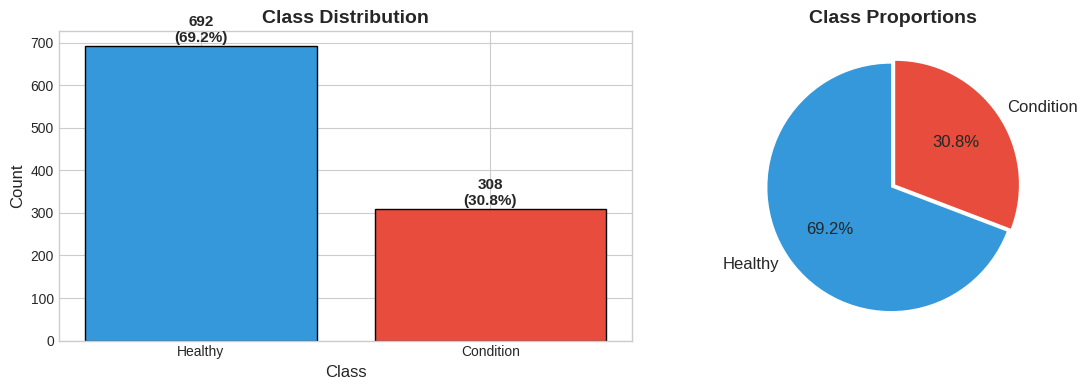

In [3]:
# Visualize the class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts = df['target_label'].value_counts()
colors = ['#3498db', '#e74c3c']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, (label, count) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, count + 10, f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.02, 0.02),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.6 Train-Test Split

<div style="background-color: #e8f5e9; padding: 20px; border-radius: 10px; border-left: 5px solid #4caf50;">

### Why Split the Data?

- **Training Set (70%)**: Used to train the model
- **Test Set (30%)**: Used to evaluate performance on unseen data

**Important:** We use `stratify=y` to maintain the same class proportions in both sets.

</div>

In [4]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,           # 30% for testing
    random_state=RANDOM_STATE,
    stratify=y                # Maintain class proportions
)

print("Data Split Complete!")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  Healthy (0):   {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Condition (1): {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"\nTest class distribution:")
print(f"  Healthy (0):   {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"  Condition (1): {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.1f}%)")

Data Split Complete!
Training set: 700 samples
Test set:     300 samples

Training class distribution:
  Healthy (0):   484 (69.1%)
  Condition (1): 216 (30.9%)

Test class distribution:
  Healthy (0):   208 (69.3%)
  Condition (1): 92 (30.7%)


## 1.7 Training Our First Classifier

We'll use **Logistic Regression** - a simple but effective classifier that also gives us probability scores.

In [5]:
# Train a Logistic Regression model
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

# Make predictions
y_pred = model.predict(X_test)              # Hard predictions: 0 or 1
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1

print(f"\nPredictions made on {len(y_test)} test samples.")

✅ Model trained successfully!

Predictions made on 300 test samples.


In [6]:
# Examine some predictions
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': np.round(y_prob, 3),
    'Correct': y_test == y_pred
})

print("Sample Predictions (first 15 test samples):")
print("=" * 55)
print(results_df.head(15).to_string(index=False))
print("=" * 55)
print(f"\nTotal correct in sample: {results_df.head(15)['Correct'].sum()}/15")

Sample Predictions (first 15 test samples):
 Actual  Predicted  Probability  Correct
      1          1        0.613     True
      0          0        0.012     True
      1          1        0.725     True
      0          0        0.040     True
      1          1        0.666     True
      1          0        0.242    False
      1          1        0.702     True
      0          1        0.886    False
      1          0        0.350    False
      0          0        0.059     True
      0          0        0.125     True
      1          1        0.526     True
      0          0        0.495     True
      0          0        0.022     True
      0          0        0.196     True

Total correct in sample: 12/15


## 1.8 Task 1 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### What We've Accomplished

1. ✅ Understood what classification is and its types
2. ✅ Set up our Python environment
3. ✅ Created a synthetic medical diagnosis dataset
4. ✅ Split data into training and test sets
5. ✅ Trained a logistic regression classifier
6. ✅ Generated predictions and probabilities

### Key Variables for Next Tasks

| Variable | Description |
|----------|-------------|
| `y_test` | Actual labels (ground truth) |
| `y_pred` | Predicted labels (0 or 1) |
| `y_prob` | Predicted probabilities (0 to 1) |

</div>

---

**Next:** Task 2 - The Confusion Matrix

---

# Task 2: The Confusion Matrix - Foundation of All Metrics

---

## 2.1 Learning Objectives

By the end of this task, you will:
- Understand what a confusion matrix is and why it matters
- Learn the four fundamental outcomes: TP, TN, FP, FN
- Be able to calculate and visualize a confusion matrix
- Understand errors as Type I and Type II errors
- Connect confusion matrix concepts to real-world scenarios

---

---

# Task 1: Setup & The Classification Problem

---

## 1.1 Learning Objectives

By the end of this task, you will:
- Understand what classification is and its types
- Set up your Python environment with necessary libraries
- Create a sample dataset for experimentation
- Train your first classifier

---

# Classification Metrics: A Complete Progressive Guide
## From Fundamentals to MLOps-Ready Evaluation

---

**Course:** CMPE 258 - Deep Learning (Spring 2026)  
**Level:** Beginner to Intermediate  
**Prerequisites:** Basic Python, familiarity with machine learning concepts

---

## Learning Roadmap

This notebook is organized into **10 progressive tasks**, each building on the previous one:

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **1** | Setup & The Classification Problem | ⭐ Beginner | ✅ |
| **2** | Confusion Matrix - Foundation of All Metrics | ⭐ Beginner | ✅ |
| **3** | Accuracy & Its Limitations | ⭐ Beginner | ⏳ |
| **4** | Precision & Recall | ⭐ Beginner | ⏳ |
| **5** | F1, F2, Fβ Scores | ⭐⭐ Intermediate | ⏳ |
| **6** | ROC Curves & AUC | ⭐⭐ Intermediate | ⏳ |
| **7** | Precision-Recall Curves | ⭐⭐ Intermediate | ⏳ |
| **8** | Multi-class Classification Metrics | ⭐⭐ Intermediate | ⏳ |
| **9** | Imbalanced Datasets & Advanced Metrics | ⭐⭐⭐ Advanced | ⏳ |
| **10** | MLOps Pipeline Metrics & Best Practices | ⭐⭐⭐ Advanced | ⏳ |

---

## 2.2 What is a Confusion Matrix?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

A **Confusion Matrix** is a table that visualizes the performance of a classification model by comparing predicted labels against actual labels.

**Why "Confusion"?** Because it shows where the model gets **confused** between classes!

</div>

### The 2×2 Structure (Binary Classification)

For binary classification, the confusion matrix is a 2×2 table:

```
                        PREDICTED
                    Negative    Positive
              ┌────────────┬────────────┐
    Negative  │     TN     │     FP     │
ACTUAL        ├────────────┼────────────┤
    Positive  │     FN     │     TP     │
              └────────────┴────────────┘
```

Each cell counts the number of samples that fall into that category.

## 2.3 The Four Fundamental Outcomes

<div style="display: flex; gap: 15px; flex-wrap: wrap; margin: 20px 0;">

<div style="flex: 1; min-width: 220px; background-color: #d4edda; padding: 20px; border-radius: 10px; border: 2px solid #28a745;">

### ✅ True Positive (TP)
**Correctly predicted POSITIVE**

- Actual: Positive
- Predicted: Positive
- Model said YES, and it was RIGHT

*Medical: Patient has disease, test detected it*

</div>

<div style="flex: 1; min-width: 220px; background-color: #d4edda; padding: 20px; border-radius: 10px; border: 2px solid #28a745;">

### ✅ True Negative (TN)
**Correctly predicted NEGATIVE**

- Actual: Negative
- Predicted: Negative  
- Model said NO, and it was RIGHT

*Medical: Patient healthy, test confirmed it*

</div>

<div style="flex: 1; min-width: 220px; background-color: #f8d7da; padding: 20px; border-radius: 10px; border: 2px solid #dc3545;">

### ❌ False Positive (FP)
**Incorrectly predicted POSITIVE**

- Actual: Negative
- Predicted: Positive
- Model said YES, but it was WRONG

*Medical: Patient healthy, but test said diseased*

**Also called: Type I Error, False Alarm**

</div>

<div style="flex: 1; min-width: 220px; background-color: #f8d7da; padding: 20px; border-radius: 10px; border: 2px solid #dc3545;">

### ❌ False Negative (FN)
**Incorrectly predicted NEGATIVE**

- Actual: Positive
- Predicted: Negative
- Model said NO, but it was WRONG

*Medical: Patient diseased, but test said healthy*

**Also called: Type II Error, Miss**

</div>

</div>

## 2.4 Memory Trick: How to Remember TP, TN, FP, FN

<div style="background-color: #fff9c4; padding: 20px; border-radius: 10px; border-left: 5px solid #fbc02d;">

### The Two-Word System

Each outcome has **two words**:

1. **First word (True/False)**: Was the prediction **correct**?
   - **True** = Correct prediction ✅
   - **False** = Wrong prediction ❌

2. **Second word (Positive/Negative)**: What did the model **predict**?
   - **Positive** = Model predicted class 1
   - **Negative** = Model predicted class 0

### Examples:
- **True Positive**: Prediction was **correct** (True), and prediction was **Positive**
- **False Negative**: Prediction was **wrong** (False), and prediction was **Negative**

</div>

## 2.5 Computing the Confusion Matrix

Let's import the confusion matrix function and compute it for our model's predictions.

In [7]:
# Import confusion matrix from sklearn
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
# Note: y_test and y_pred were created in Task 1
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print("=" * 30)
print(cm)
print("=" * 30)
print(f"\nMatrix shape: {cm.shape}")

Confusion Matrix:
[[187  21]
 [ 40  52]]

Matrix shape: (2, 2)


In [8]:
# Extract the four values from confusion matrix
# sklearn returns: [[TN, FP], [FN, TP]]
TN, FP, FN, TP = cm.ravel()

print("Extracting Values from Confusion Matrix:")
print("=" * 50)
print(f"""
              PREDICTED
           Neg      Pos
         ┌────────┬────────┐
    Neg  │ TN={TN:3d} │ FP={FP:3d} │
ACTUAL   ├────────┼────────┤
    Pos  │ FN={FN:3d} │ TP={TP:3d} │
         └────────┴────────┘
""")
print("=" * 50)
print(f"\n✅ Correct Predictions:  TN + TP = {TN} + {TP} = {TN + TP}")
print(f"❌ Wrong Predictions:    FP + FN = {FP} + {FN} = {FP + FN}")
print(f"📊 Total Predictions:    {TN + FP + FN + TP}")

Extracting Values from Confusion Matrix:

              PREDICTED
           Neg      Pos
         ┌────────┬────────┐
    Neg  │ TN=187 │ FP= 21 │
ACTUAL   ├────────┼────────┤
    Pos  │ FN= 40 │ TP= 52 │
         └────────┴────────┘


✅ Correct Predictions:  TN + TP = 187 + 52 = 239
❌ Wrong Predictions:    FP + FN = 21 + 40 = 61
📊 Total Predictions:    300


## 2.6 Visualizing the Confusion Matrix

A good visualization makes the confusion matrix easier to interpret at a glance.

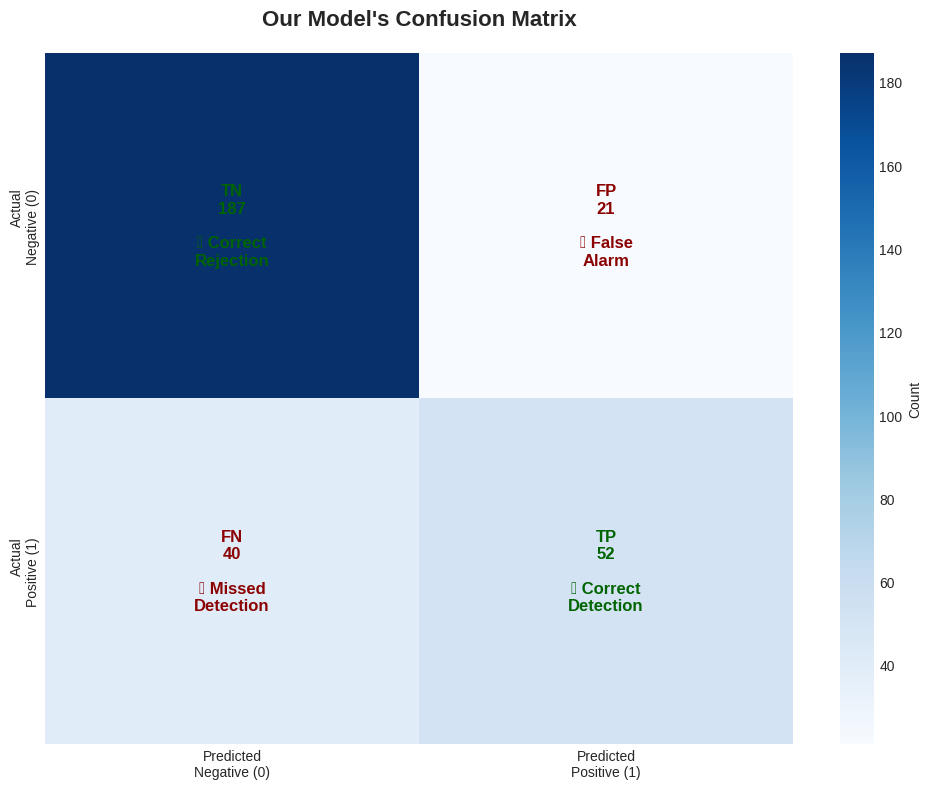

In [9]:
def plot_confusion_matrix_detailed(cm, title='Confusion Matrix'):
    """
    Create a detailed, annotated confusion matrix visualization.

    Parameters:
    -----------
    cm : array-like
        2x2 confusion matrix
    title : str
        Title for the plot
    """
    TN, FP, FN, TP = cm.ravel()

    fig, ax = plt.subplots(figsize=(10, 8))

    # Create heatmap with custom colors
    # Green for correct (diagonal), Red for incorrect (off-diagonal)
    colors = np.array([[0.8, 0.2],   # TN is correct, FP is wrong
                       [0.2, 0.8]])   # FN is wrong, TP is correct

    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
                xticklabels=['Predicted\nNegative (0)', 'Predicted\nPositive (1)'],
                yticklabels=['Actual\nNegative (0)', 'Actual\nPositive (1)'],
                cbar_kws={'label': 'Count'})

    # Add detailed annotations
    annotations = [
        [f'TN\n{TN}\n\n✅ Correct\nRejection', f'FP\n{FP}\n\n❌ False\nAlarm'],
        [f'FN\n{FN}\n\n❌ Missed\nDetection', f'TP\n{TP}\n\n✅ Correct\nDetection']
    ]

    for i in range(2):
        for j in range(2):
            color = 'darkgreen' if i == j else 'darkred'
            ax.text(j + 0.5, i + 0.5, annotations[i][j],
                   ha='center', va='center', fontsize=12,
                   color=color, fontweight='bold')

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Visualize our confusion matrix
plot_confusion_matrix_detailed(cm, "Our Model's Confusion Matrix")

## 2.7 Type I and Type II Errors

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Statistical Perspective

In statistics, we frame classification errors as hypothesis testing:

| Error Type | Also Known As | What Happened | Confusion Matrix |
|------------|---------------|---------------|------------------|
| **Type I Error** | False Positive, α error | Rejected a true null hypothesis | FP |
| **Type II Error** | False Negative, β error | Failed to reject a false null hypothesis | FN |

### The Courtroom Analogy

Think of a criminal trial:
- **Null Hypothesis (H₀)**: Defendant is innocent
- **Alternative Hypothesis (H₁)**: Defendant is guilty

| Outcome | Reality: Innocent | Reality: Guilty |
|---------|-------------------|-----------------|
| **Verdict: Not Guilty** | ✅ Correct (TN) | ❌ Type II Error - Criminal goes free (FN) |
| **Verdict: Guilty** | ❌ Type I Error - Innocent jailed (FP) | ✅ Correct (TP) |

</div>

## 2.8 Real-World Impact: Which Error is Worse?

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### The Answer: It Depends on the Problem!

Different domains have different tolerances for FP vs FN errors.

</div>

### Examples Where False Negatives (FN) Are Worse

| Domain | Positive Class | Why FN is Critical |
|--------|----------------|-------------------|
| **Cancer Screening** | Has cancer | Missing cancer → patient doesn't get treatment → death |
| **Fraud Detection** | Fraudulent transaction | Missing fraud → financial loss |
| **Airport Security** | Threat detected | Missing a threat → catastrophic consequences |
| **Disease Outbreak** | Infected person | Missing infected → disease spreads |

### Examples Where False Positives (FP) Are Worse

| Domain | Positive Class | Why FP is Critical |
|--------|----------------|-------------------|
| **Email Spam Filter** | Is spam | Important email in spam → missed opportunity |
| **Criminal Justice** | Guilty | Innocent person convicted → life ruined |
| **Drug Testing (athletes)** | Used drugs | False accusation → career destroyed |
| **Hiring Algorithm** | Good candidate | Rejecting good candidates → company loses talent |

## 2.9 Hands-On: Analyzing Our Model's Errors

Let's look at specific examples where our model made mistakes.

In [10]:
# Create a detailed results DataFrame
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_prob,
    'Actual_Label': ['Healthy' if y == 0 else 'Condition' for y in y_test],
    'Predicted_Label': ['Healthy' if y == 0 else 'Condition' for y in y_pred],
})

# Classify each prediction into TP, TN, FP, FN
def classify_outcome(row):
    if row['Actual'] == 1 and row['Predicted'] == 1:
        return 'TP (True Positive)'
    elif row['Actual'] == 0 and row['Predicted'] == 0:
        return 'TN (True Negative)'
    elif row['Actual'] == 0 and row['Predicted'] == 1:
        return 'FP (False Positive)'
    else:
        return 'FN (False Negative)'

results['Outcome'] = results.apply(classify_outcome, axis=1)

# Display outcome distribution
print("Outcome Distribution:")
print("=" * 40)
print(results['Outcome'].value_counts().to_string())
print("=" * 40)

Outcome Distribution:
Outcome
TN (True Negative)     187
TP (True Positive)      52
FN (False Negative)     40
FP (False Positive)     21


In [11]:
# Show examples of each outcome type
print("\n" + "=" * 70)
print("EXAMPLES OF EACH OUTCOME TYPE")
print("=" * 70)

for outcome_type in ['TP (True Positive)', 'TN (True Negative)',
                      'FP (False Positive)', 'FN (False Negative)']:
    subset = results[results['Outcome'] == outcome_type]
    print(f"\n{outcome_type} - {len(subset)} cases")
    print("-" * 50)
    if len(subset) > 0:
        # Show up to 3 examples
        sample = subset.head(3)[['Actual_Label', 'Predicted_Label', 'Probability']]
        sample['Probability'] = sample['Probability'].round(3)
        print(sample.to_string(index=False))
    else:
        print("No cases found")


EXAMPLES OF EACH OUTCOME TYPE

TP (True Positive) - 52 cases
--------------------------------------------------
Actual_Label Predicted_Label  Probability
   Condition       Condition        0.613
   Condition       Condition        0.725
   Condition       Condition        0.666

TN (True Negative) - 187 cases
--------------------------------------------------
Actual_Label Predicted_Label  Probability
     Healthy         Healthy        0.012
     Healthy         Healthy        0.040
     Healthy         Healthy        0.059

FP (False Positive) - 21 cases
--------------------------------------------------
Actual_Label Predicted_Label  Probability
     Healthy       Condition        0.886
     Healthy       Condition        0.718
     Healthy       Condition        0.586

FN (False Negative) - 40 cases
--------------------------------------------------
Actual_Label Predicted_Label  Probability
   Condition         Healthy        0.242
   Condition         Healthy        0.350
   Condi

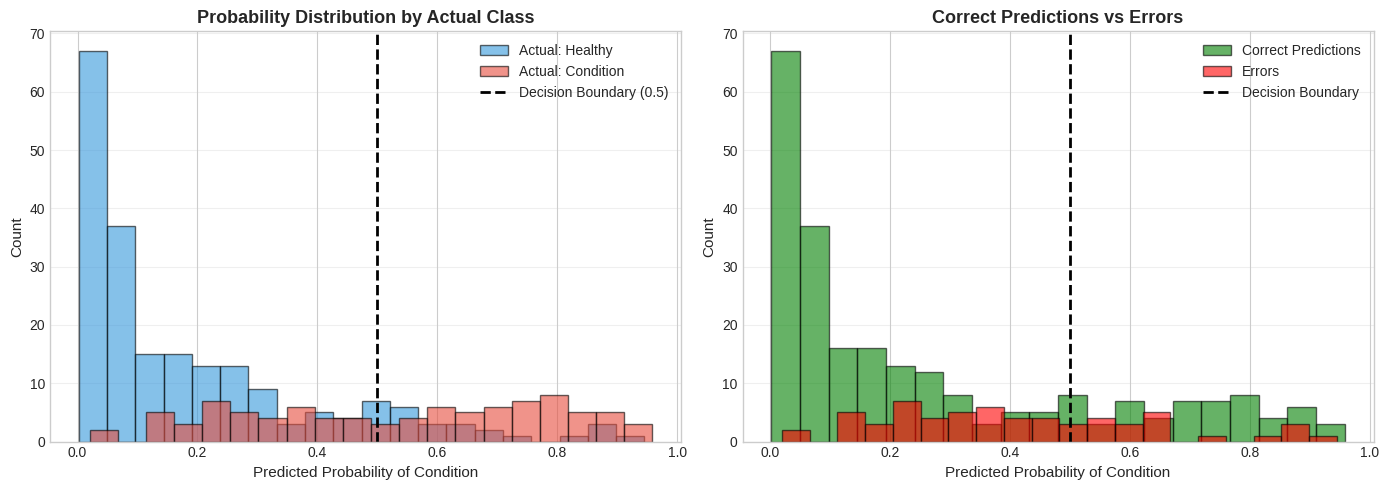


💡 Insight: Errors tend to occur when probability is close to 0.5 (model is uncertain)
   Confident predictions (probability near 0 or 1) are more likely to be correct.


In [12]:
# Visualize probability distributions by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability distribution by actual class
for actual_class, color, label in [(0, '#3498db', 'Actual: Healthy'),
                                    (1, '#e74c3c', 'Actual: Condition')]:
    subset = results[results['Actual'] == actual_class]['Probability']
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')

axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
axes[0].set_xlabel('Predicted Probability of Condition', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Probability Distribution by Actual Class', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Errors analysis
error_probs = results[results['Outcome'].str.contains('False')]['Probability']
correct_probs = results[results['Outcome'].str.contains('True')]['Probability']

axes[1].hist(correct_probs, bins=20, alpha=0.6, color='green', label='Correct Predictions', edgecolor='black')
axes[1].hist(error_probs, bins=20, alpha=0.6, color='red', label='Errors', edgecolor='black')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
axes[1].set_xlabel('Predicted Probability of Condition', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Correct Predictions vs Errors', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Insight: Errors tend to occur when probability is close to 0.5 (model is uncertain)")
print("   Confident predictions (probability near 0 or 1) are more likely to be correct.")

## 2.10 The Math: Key Relationships

<div style="background-color: #e3f2fd; padding: 20px; border-radius: 10px; border-left: 5px solid #2196f3;">

### From the Confusion Matrix, We Can Derive:

**Total Samples:**
$$N = TP + TN + FP + FN$$

**Actual Positives (P):**
$$P = TP + FN$$

**Actual Negatives (N):**
$$N = TN + FP$$

**Predicted Positives:**
$$PP = TP + FP$$

**Predicted Negatives:**
$$PN = TN + FN$$

### These relationships form the foundation for ALL classification metrics!

</div>

In [13]:
# Verify the mathematical relationships
print("Mathematical Relationships Verification")
print("=" * 50)

# Calculate derived values
total_samples = TP + TN + FP + FN
actual_positives = TP + FN      # People who actually have the condition
actual_negatives = TN + FP      # People who are actually healthy
predicted_positives = TP + FP   # People we predicted have the condition
predicted_negatives = TN + FN   # People we predicted are healthy

print(f"""
From our confusion matrix:
  TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}

Derived Values:
  Total Samples:       TP + TN + FP + FN = {total_samples}
  Actual Positives:    TP + FN = {actual_positives}
  Actual Negatives:    TN + FP = {actual_negatives}
  Predicted Positives: TP + FP = {predicted_positives}
  Predicted Negatives: TN + FN = {predicted_negatives}

Verification:
  Actual Pos + Actual Neg = {actual_positives} + {actual_negatives} = {actual_positives + actual_negatives} ✓
  Pred Pos + Pred Neg = {predicted_positives} + {predicted_negatives} = {predicted_positives + predicted_negatives} ✓
""")

Mathematical Relationships Verification

From our confusion matrix:
  TP = 52, TN = 187, FP = 21, FN = 40

Derived Values:
  Total Samples:       TP + TN + FP + FN = 300
  Actual Positives:    TP + FN = 92
  Actual Negatives:    TN + FP = 208
  Predicted Positives: TP + FP = 73
  Predicted Negatives: TN + FN = 227

Verification:
  Actual Pos + Actual Neg = 92 + 208 = 300 ✓
  Pred Pos + Pred Neg = 73 + 227 = 300 ✓



# Classification Metrics: A Complete Progressive Guide
## From Fundamentals to MLOps-Ready Evaluation

---

**Course:** CMPE 258 - Deep Learning (Spring 2026)  
**Level:** Beginner to Intermediate  
**Prerequisites:** Basic Python, familiarity with machine learning concepts

---

## Learning Roadmap

This notebook is organized into **10 progressive tasks**, each building on the previous one:

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **1** | Setup & The Classification Problem | ⭐ Beginner | ✅ |
| **2** | Confusion Matrix - Foundation of All Metrics | ⭐ Beginner | ✅ |
| **3** | Accuracy & Its Limitations | ⭐ Beginner | ✅ |
| **4** | Precision & Recall | ⭐ Beginner | ⏳ |
| **5** | F1, F2, Fβ Scores | ⭐⭐ Intermediate | ⏳ |
| **6** | ROC Curves & AUC | ⭐⭐ Intermediate | ⏳ |
| **7** | Precision-Recall Curves | ⭐⭐ Intermediate | ⏳ |
| **8** | Multi-class Classification Metrics | ⭐⭐ Intermediate | ⏳ |
| **9** | Imbalanced Datasets & Advanced Metrics | ⭐⭐⭐ Advanced | ⏳ |
| **10** | MLOps Pipeline Metrics & Best Practices | ⭐⭐⭐ Advanced | ⏳ |

---

## 2.11 Task 2 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### What We've Accomplished

1. ✅ Understood the confusion matrix structure
2. ✅ Learned the four outcomes: TP, TN, FP, FN
3. ✅ Connected to Type I and Type II errors
4. ✅ Visualized the confusion matrix
5. ✅ Analyzed real errors from our model
6. ✅ Understood the mathematical relationships

### Key Takeaways

| Concept | Remember |
|---------|----------|
| **True/False** | Was the prediction correct? |
| **Positive/Negative** | What was predicted? |
| **FP (Type I)** | False alarm - predicted positive but was negative |
| **FN (Type II)** | Missed detection - predicted negative but was positive |

### Key Variables for Next Tasks

| Variable | Description |
|----------|-------------|
| `TP, TN, FP, FN` | The four confusion matrix values |
| `cm` | The confusion matrix array |

</div>

---

**Next:** Task 3 - Accuracy & Its Limitations

---

# Task 3: Accuracy & Its Limitations

---

## 3.1 Learning Objectives

By the end of this task, you will:
- Understand accuracy as a metric and its formula
- Calculate accuracy from the confusion matrix
- Recognize the **Accuracy Paradox**
- Understand when accuracy is misleading
- Learn about balanced accuracy as an alternative

---

## 3.2 What is Accuracy?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**Accuracy** is the proportion of correct predictions out of all predictions made.

$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

</div>

### Intuition

Accuracy answers the question: **"Out of all predictions I made, what percentage were correct?"**

### Properties
- Range: 0 to 1 (or 0% to 100%)
- Higher is better
- Simple to understand and calculate
- **BUT: Can be very misleading!** (more on this soon)

## 3.3 Calculating Accuracy

In [14]:
# Import accuracy_score from sklearn
from sklearn.metrics import accuracy_score

# Method 1: Calculate accuracy manually from confusion matrix values
accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy Calculation")
print("=" * 50)
print(f"\nMethod 1: Manual calculation from confusion matrix")
print(f"  Accuracy = (TP + TN) / (TP + TN + FP + FN)")
print(f"  Accuracy = ({TP} + {TN}) / ({TP} + {TN} + {FP} + {FN})")
print(f"  Accuracy = {TP + TN} / {TP + TN + FP + FN}")
print(f"  Accuracy = {accuracy_manual:.4f}")

# Method 2: Using sklearn
accuracy_sklearn = accuracy_score(y_test, y_pred)
print(f"\nMethod 2: Using sklearn.metrics.accuracy_score")
print(f"  Accuracy = {accuracy_sklearn:.4f}")

# As percentage
print(f"\n📊 Our model correctly classified {accuracy_sklearn*100:.2f}% of test samples!")

Accuracy Calculation

Method 1: Manual calculation from confusion matrix
  Accuracy = (TP + TN) / (TP + TN + FP + FN)
  Accuracy = (52 + 187) / (52 + 187 + 21 + 40)
  Accuracy = 239 / 300
  Accuracy = 0.7967

Method 2: Using sklearn.metrics.accuracy_score
  Accuracy = 0.7967

📊 Our model correctly classified 79.67% of test samples!


## 3.4 When Accuracy Works Well

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Accuracy is a Good Metric When:

1. **Classes are balanced** (roughly equal number of positives and negatives)
2. **Both types of errors are equally important** (FP and FN have similar costs)
3. **You need a quick, simple evaluation**

</div>

### Example: Balanced Dataset

In [15]:
# Create a balanced dataset example
np.random.seed(42)

# Balanced: 50% positive, 50% negative
y_balanced_true = np.array([0]*50 + [1]*50)
y_balanced_pred = np.array([0]*45 + [1]*5 + [0]*8 + [1]*42)  # Some errors

cm_balanced = confusion_matrix(y_balanced_true, y_balanced_pred)
acc_balanced = accuracy_score(y_balanced_true, y_balanced_pred)

print("Balanced Dataset Example")
print("=" * 50)
print(f"Class distribution: 50 negatives, 50 positives (50/50)")
print(f"\nConfusion Matrix:")
print(cm_balanced)
print(f"\nAccuracy: {acc_balanced:.2%}")
print(f"\n✅ With balanced classes, accuracy is a reasonable metric!")

Balanced Dataset Example
Class distribution: 50 negatives, 50 positives (50/50)

Confusion Matrix:
[[45  5]
 [ 8 42]]

Accuracy: 87.00%

✅ With balanced classes, accuracy is a reasonable metric!


## 3.5 The Accuracy Paradox

<div style="background-color: #f8d7da; padding: 20px; border-radius: 10px; border-left: 5px solid #dc3545;">

### The Problem

**The Accuracy Paradox** occurs when a model achieves high accuracy but is actually useless or even harmful.

This happens with **imbalanced datasets** - when one class is much more common than the other.

### Real-World Example: Fraud Detection

Imagine a credit card fraud detection system:
- **99%** of transactions are legitimate
- **1%** of transactions are fraudulent

A model that **ALWAYS predicts "legitimate"** achieves **99% accuracy** but catches **ZERO fraud!**

</div>

In [16]:
# Demonstrate the Accuracy Paradox
print("=" * 60)
print("THE ACCURACY PARADOX DEMONSTRATION")
print("=" * 60)

# Create a highly imbalanced dataset (like fraud detection)
# 99% legitimate (class 0), 1% fraud (class 1)
n_samples = 10000
n_fraud = 100  # 1% fraud
n_legitimate = 9900  # 99% legitimate

y_imbalanced_true = np.array([0] * n_legitimate + [1] * n_fraud)

# Model A: "Dumb" model - always predicts legitimate (0)
y_pred_dumb = np.zeros_like(y_imbalanced_true)

# Model B: "Smart" model - catches 70% of fraud but has some false positives
y_pred_smart = y_imbalanced_true.copy()
# Miss 30% of fraud (30 FN)
fraud_indices = np.where(y_imbalanced_true == 1)[0]
np.random.seed(42)
missed_fraud = np.random.choice(fraud_indices, size=30, replace=False)
y_pred_smart[missed_fraud] = 0
# Add some false positives (50 FP)
legit_indices = np.where(y_imbalanced_true == 0)[0]
false_alarms = np.random.choice(legit_indices, size=50, replace=False)
y_pred_smart[false_alarms] = 1

# Calculate accuracies
acc_dumb = accuracy_score(y_imbalanced_true, y_pred_dumb)
acc_smart = accuracy_score(y_imbalanced_true, y_pred_smart)

print(f"\nDataset: {n_samples:,} transactions")
print(f"  - Legitimate: {n_legitimate:,} (99%)")
print(f"  - Fraud: {n_fraud:,} (1%)")

print(f"\n{'Model':<20} {'Accuracy':<15} {'Fraud Caught':<15}")
print("-" * 50)
print(f"{'Dumb (all legit)':<20} {acc_dumb:.2%}{'':>5} {0}/{n_fraud} (0%)")
print(f"{'Smart (ML model)':<20} {acc_smart:.2%}{'':>5} {70}/{n_fraud} (70%)")

print("\n⚠️  THE PARADOX: The 'dumb' model has HIGHER accuracy!")
print("   But it catches ZERO fraud - completely useless!")

THE ACCURACY PARADOX DEMONSTRATION

Dataset: 10,000 transactions
  - Legitimate: 9,900 (99%)
  - Fraud: 100 (1%)

Model                Accuracy        Fraud Caught   
--------------------------------------------------
Dumb (all legit)     99.00%      0/100 (0%)
Smart (ML model)     99.20%      70/100 (70%)

⚠️  THE PARADOX: The 'dumb' model has HIGHER accuracy!
   But it catches ZERO fraud - completely useless!


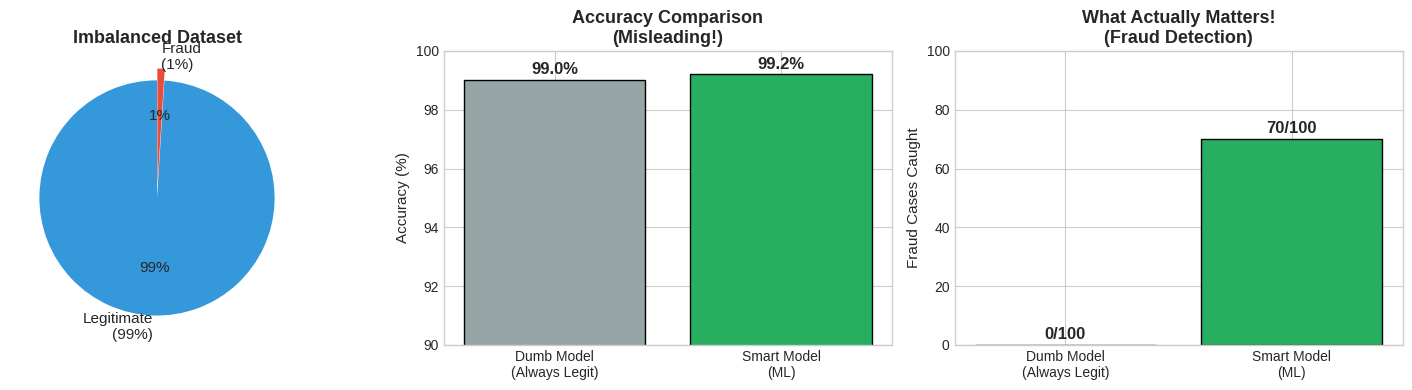

In [17]:
# Visualize the accuracy paradox
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Class distribution
labels = ['Legitimate\n(99%)', 'Fraud\n(1%)']
sizes = [99, 1]
colors = ['#3498db', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
            startangle=90, explode=(0, 0.1), textprops={'fontsize': 11})
axes[0].set_title('Imbalanced Dataset', fontsize=13, fontweight='bold')

# Plot 2: Accuracy comparison (misleading!)
models = ['Dumb Model\n(Always Legit)', 'Smart Model\n(ML)']
accuracies = [acc_dumb * 100, acc_smart * 100]
bars = axes[1].bar(models, accuracies, color=['#95a5a6', '#27ae60'], edgecolor='black')
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Accuracy Comparison\n(Misleading!)', fontsize=13, fontweight='bold')
axes[1].set_ylim([90, 100])
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Plot 3: What actually matters - fraud caught
fraud_caught = [0, 70]
bars = axes[2].bar(models, fraud_caught, color=['#e74c3c', '#27ae60'], edgecolor='black')
axes[2].set_ylabel('Fraud Cases Caught', fontsize=11)
axes[2].set_title('What Actually Matters!\n(Fraud Detection)', fontsize=13, fontweight='bold')
axes[2].set_ylim([0, 100])
for bar, caught in zip(bars, fraud_caught):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{caught}/100', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.6 Balanced Accuracy: A Better Alternative

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Definition

**Balanced Accuracy** is the average of recall obtained on each class.

$$\text{Balanced Accuracy} = \frac{1}{2}\left(\frac{TP}{TP+FN} + \frac{TN}{TN+FP}\right) = \frac{\text{Sensitivity} + \text{Specificity}}{2}$$

### Why It's Better

- Gives **equal weight** to each class regardless of size
- A model predicting all one class gets 50% (not 99%!)
- Better reflects actual model performance on minority class

</div>

In [18]:
# Import balanced_accuracy_score
from sklearn.metrics import balanced_accuracy_score

# Calculate balanced accuracy for both models
bal_acc_dumb = balanced_accuracy_score(y_imbalanced_true, y_pred_dumb)
bal_acc_smart = balanced_accuracy_score(y_imbalanced_true, y_pred_smart)

print("Balanced Accuracy Comparison")
print("=" * 60)
print(f"\n{'Model':<20} {'Accuracy':<15} {'Balanced Accuracy':<20}")
print("-" * 60)
print(f"{'Dumb (all legit)':<20} {acc_dumb:.2%}{'':>5} {bal_acc_dumb:.2%}")
print(f"{'Smart (ML model)':<20} {acc_smart:.2%}{'':>5} {bal_acc_smart:.2%}")

print("\n✅ Balanced accuracy correctly shows:")
print(f"   - Dumb model: {bal_acc_dumb:.0%} (essentially random guessing)")
print(f"   - Smart model: {bal_acc_smart:.0%} (actually useful!)")

Balanced Accuracy Comparison

Model                Accuracy        Balanced Accuracy   
------------------------------------------------------------
Dumb (all legit)     99.00%      50.00%
Smart (ML model)     99.20%      84.75%

✅ Balanced accuracy correctly shows:
   - Dumb model: 50% (essentially random guessing)
   - Smart model: 85% (actually useful!)


## 3.7 When to Use (and Not Use) Accuracy

<div style="display: flex; gap: 20px; flex-wrap: wrap;">

<div style="flex: 1; min-width: 280px; background-color: #d4edda; padding: 20px; border-radius: 10px; border: 2px solid #28a745;">

### ✅ Use Accuracy When:

- Classes are **balanced** (similar counts)
- Both error types have **similar costs**
- You need a **quick baseline** metric
- Comparing models on the **same balanced** dataset

</div>

<div style="flex: 1; min-width: 280px; background-color: #f8d7da; padding: 20px; border-radius: 10px; border: 2px solid #dc3545;">

### ❌ Avoid Accuracy When:

- Classes are **imbalanced**
- One error type is much **more costly**
- Working with **rare event detection**
  - Fraud, disease, defects, etc.
- Need to understand **per-class** performance

</div>

</div>

# Classification Metrics: A Complete Progressive Guide
## From Fundamentals to MLOps-Ready Evaluation

---

**Course:** CMPE 258 - Deep Learning (Spring 2026)  
**Level:** Beginner to Intermediate  
**Prerequisites:** Basic Python, familiarity with machine learning concepts

---

## Learning Roadmap

This notebook is organized into **10 progressive tasks**, each building on the previous one:

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **1** | Setup & The Classification Problem | ⭐ Beginner | ✅ |
| **2** | Confusion Matrix - Foundation of All Metrics | ⭐ Beginner | ✅ |
| **3** | Accuracy & Its Limitations | ⭐ Beginner | ✅ |
| **4** | Precision & Recall | ⭐ Beginner | ✅ |
| **5** | F1, F2, Fβ Scores | ⭐⭐ Intermediate | ⏳ |
| **6** | ROC Curves & AUC | ⭐⭐ Intermediate | ⏳ |
| **7** | Precision-Recall Curves | ⭐⭐ Intermediate | ⏳ |
| **8** | Multi-class Classification Metrics | ⭐⭐ Intermediate | ⏳ |
| **9** | Imbalanced Datasets & Advanced Metrics | ⭐⭐⭐ Advanced | ⏳ |
| **10** | MLOps Pipeline Metrics & Best Practices | ⭐⭐⭐ Advanced | ⏳ |

---

---

# Task 4: Precision & Recall

---

## 4.1 Learning Objectives

By the end of this task, you will:
- Understand precision and recall definitions and formulas
- Know when to prioritize precision vs recall
- Understand the precision-recall trade-off
- Calculate these metrics using scikit-learn
- Apply these concepts to real-world scenarios

---

## 4.2 Precision: "When I Predict Positive, Am I Right?"

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**Precision** (also called **Positive Predictive Value**) measures the accuracy of positive predictions.

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{\text{True Positives}}{\text{All Predicted Positives}}$$

</div>

### Intuition

Precision answers: **"Of all the samples I predicted as positive, how many were actually positive?"**

### Visual Representation

```
All Predicted Positives (TP + FP)
┌─────────────────────────────────┐
│    TP (correct)   │  FP (wrong) │
└─────────────────────────────────┘
         ↑
   Precision = TP / (TP + FP)
```

In [19]:
# Import precision_score
from sklearn.metrics import precision_score

# Calculate precision manually
precision_manual = TP / (TP + FP)
print("Precision Calculation")
print("=" * 50)
print(f"\nManual calculation:")
print(f"  Precision = TP / (TP + FP)")
print(f"  Precision = {TP} / ({TP} + {FP})")
print(f"  Precision = {TP} / {TP + FP}")
print(f"  Precision = {precision_manual:.4f}")

# Using sklearn
precision_sklearn = precision_score(y_test, y_pred)
print(f"\nUsing sklearn: {precision_sklearn:.4f}")

print(f"\n📊 Interpretation: When our model predicts 'Condition',")
print(f"   it's correct {precision_sklearn*100:.1f}% of the time.")

Precision Calculation

Manual calculation:
  Precision = TP / (TP + FP)
  Precision = 52 / (52 + 21)
  Precision = 52 / 73
  Precision = 0.7123

Using sklearn: 0.7123

📊 Interpretation: When our model predicts 'Condition',
   it's correct 71.2% of the time.


## 4.3 Recall: "Did I Find All the Positives?"

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**Recall** (also called **Sensitivity** or **True Positive Rate**) measures the ability to find all positive samples.

$$\text{Recall} = \frac{TP}{TP + FN} = \frac{\text{True Positives}}{\text{All Actual Positives}}$$

</div>

### Intuition

Recall answers: **"Of all the actual positive samples, how many did I correctly identify?"**

### Visual Representation

```
All Actual Positives (TP + FN)
┌─────────────────────────────────┐
│    TP (found)    │  FN (missed) │
└─────────────────────────────────┘
         ↑
   Recall = TP / (TP + FN)
```

In [20]:
# Import recall_score
from sklearn.metrics import recall_score

# Calculate recall manually
recall_manual = TP / (TP + FN)
print("Recall Calculation")
print("=" * 50)
print(f"\nManual calculation:")
print(f"  Recall = TP / (TP + FN)")
print(f"  Recall = {TP} / ({TP} + {FN})")
print(f"  Recall = {TP} / {TP + FN}")
print(f"  Recall = {recall_manual:.4f}")

# Using sklearn
recall_sklearn = recall_score(y_test, y_pred)
print(f"\nUsing sklearn: {recall_sklearn:.4f}")

print(f"\n📊 Interpretation: Our model correctly identifies")
print(f"   {recall_sklearn*100:.1f}% of all patients with the condition.")

Recall Calculation

Manual calculation:
  Recall = TP / (TP + FN)
  Recall = 52 / (52 + 40)
  Recall = 52 / 92
  Recall = 0.5652

Using sklearn: 0.5652

📊 Interpretation: Our model correctly identifies
   56.5% of all patients with the condition.


## 4.4 Precision vs Recall: Side-by-Side Comparison

<div style="display: flex; gap: 20px; flex-wrap: wrap;">

<div style="flex: 1; min-width: 280px; background-color: #e3f2fd; padding: 20px; border-radius: 10px; border-left: 5px solid #2196f3;">

### Precision

**Focus:** Quality of positive predictions

**Question:** "When I say positive, am I right?"

**Denominator:** Predicted Positives (TP + FP)

**Penalizes:** False Positives (FP)

**High precision = Few false alarms**

</div>

<div style="flex: 1; min-width: 280px; background-color: #e8f5e9; padding: 20px; border-radius: 10px; border-left: 5px solid #4caf50;">

### Recall

**Focus:** Coverage of actual positives

**Question:** "Did I find all positives?"

**Denominator:** Actual Positives (TP + FN)

**Penalizes:** False Negatives (FN)

**High recall = Few missed positives**

</div>

</div>

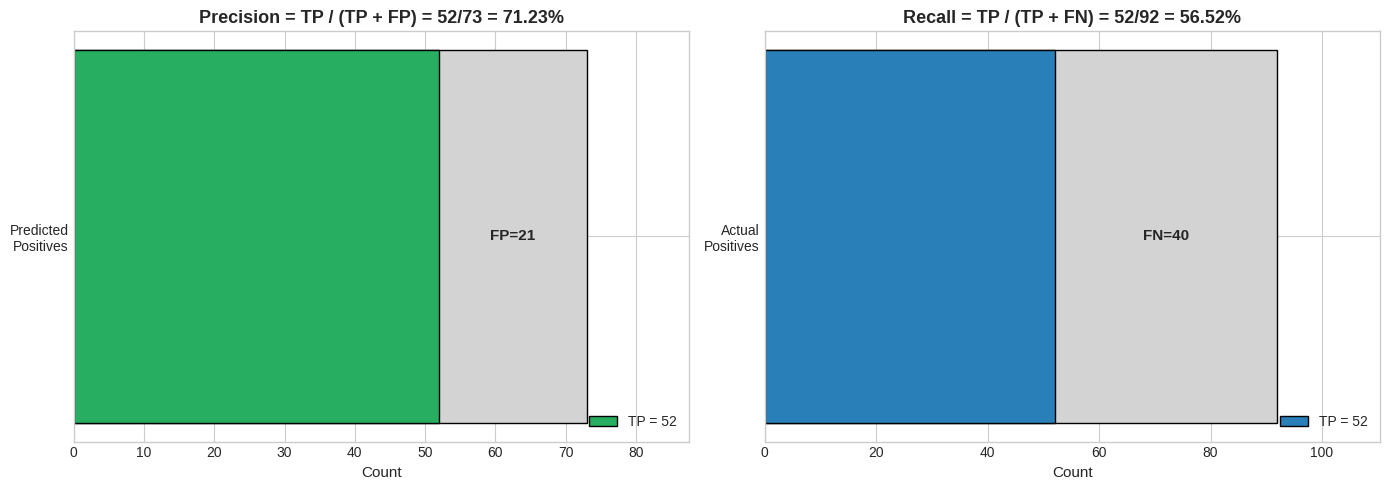

In [21]:
# Visualize precision and recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision visualization
ax1 = axes[0]
predicted_pos = TP + FP
ax1.barh(['Predicted\nPositives'], [predicted_pos], color='lightgray', edgecolor='black', height=0.5)
ax1.barh(['Predicted\nPositives'], [TP], color='#27ae60', edgecolor='black', height=0.5, label=f'TP = {TP}')
ax1.set_xlim(0, predicted_pos * 1.2)
ax1.set_title(f'Precision = TP / (TP + FP) = {TP}/{predicted_pos} = {precision_sklearn:.2%}',
              fontsize=13, fontweight='bold')
ax1.legend(loc='lower right')
ax1.text(TP + (FP/2), 0, f'FP={FP}', ha='center', va='center', fontsize=11, fontweight='bold')
ax1.set_xlabel('Count', fontsize=11)

# Recall visualization
ax2 = axes[1]
actual_pos = TP + FN
ax2.barh(['Actual\nPositives'], [actual_pos], color='lightgray', edgecolor='black', height=0.5)
ax2.barh(['Actual\nPositives'], [TP], color='#2980b9', edgecolor='black', height=0.5, label=f'TP = {TP}')
ax2.set_xlim(0, actual_pos * 1.2)
ax2.set_title(f'Recall = TP / (TP + FN) = {TP}/{actual_pos} = {recall_sklearn:.2%}',
              fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.text(TP + (FN/2), 0, f'FN={FN}', ha='center', va='center', fontsize=11, fontweight='bold')
ax2.set_xlabel('Count', fontsize=11)

plt.tight_layout()
plt.show()

## 4.5 When to Prioritize Precision vs Recall

<div style="background-color: #fff9c4; padding: 20px; border-radius: 10px; border-left: 5px solid #fbc02d;">

### The Trade-off

In most real-world scenarios, **you can't maximize both**. Improving one often hurts the other.

Think of it as a dial you can adjust based on your business needs.

</div>

### Prioritize PRECISION When:

| Scenario | Why Precision Matters | Example |
|----------|----------------------|---------|
| **Email Spam Filter** | FP = legitimate email in spam | User misses important email |
| **Recommendation System** | FP = irrelevant recommendation | User loses trust |
| **Search Engine** | FP = irrelevant result | User frustrated |
| **YouTube suggestions** | FP = unwanted video | User annoyed |

**Rule:** When false positives are **expensive or annoying**.

### Prioritize RECALL When:

| Scenario | Why Recall Matters | Example |
|----------|-------------------|---------|
| **Cancer Screening** | FN = missed cancer | Patient dies |
| **Fraud Detection** | FN = undetected fraud | Financial loss |
| **Security Threats** | FN = missed threat | Safety risk |
| **COVID Testing** | FN = infected person not isolated | Virus spreads |

**Rule:** When false negatives are **dangerous or costly**.

## 4.6 The Precision-Recall Trade-off in Action

Let's see how changing the classification threshold affects precision and recall.

In [22]:
# Demonstrate the precision-recall trade-off at different thresholds
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results_threshold = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    results_threshold.append({
        'Threshold': thresh,
        'Precision': prec,
        'Recall': rec,
        'Predicted Positives': sum(y_pred_thresh)
    })

df_thresh = pd.DataFrame(results_threshold)
print("Precision-Recall at Different Thresholds")
print("=" * 65)
print(df_thresh.to_string(index=False))
print("=" * 65)
print("\n💡 Notice: As threshold increases:")
print("   - Precision tends to increase (fewer, more confident predictions)")
print("   - Recall tends to decrease (we miss more positives)")

Precision-Recall at Different Thresholds
 Threshold  Precision   Recall  Predicted Positives
       0.1   0.466321 0.978261                  193
       0.2   0.535948 0.891304                  153
       0.3   0.617391 0.771739                  115
       0.4   0.617021 0.630435                   94
       0.5   0.712329 0.565217                   73
       0.6   0.763636 0.456522                   55
       0.7   0.837838 0.336957                   37
       0.8   0.761905 0.173913                   21
       0.9   0.800000 0.043478                    5

💡 Notice: As threshold increases:
   - Precision tends to increase (fewer, more confident predictions)
   - Recall tends to decrease (we miss more positives)


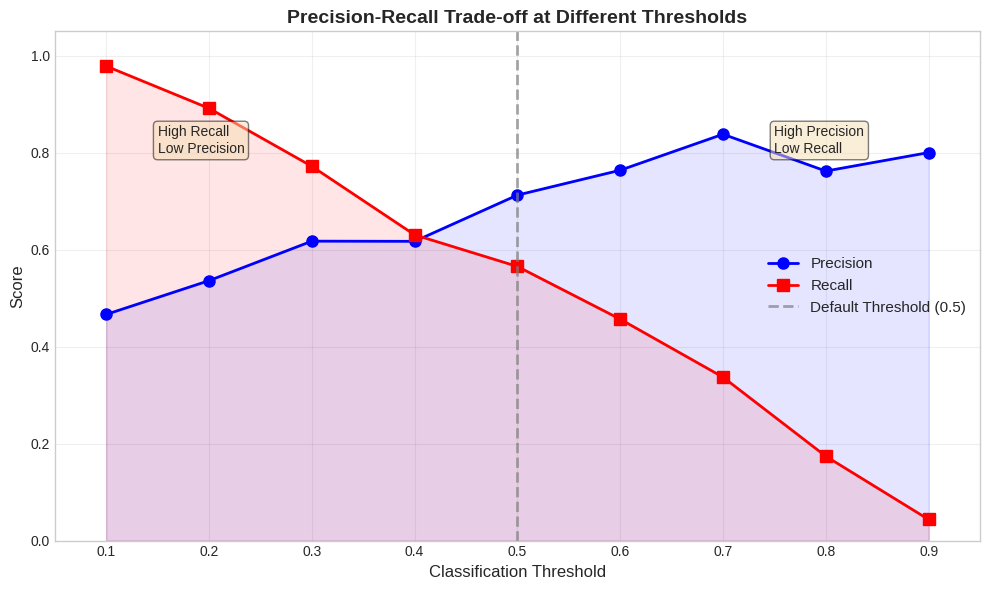

In [23]:
# Visualize the precision-recall trade-off
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_thresh['Threshold'], df_thresh['Precision'], 'b-o',
        linewidth=2, markersize=8, label='Precision')
ax.plot(df_thresh['Threshold'], df_thresh['Recall'], 'r-s',
        linewidth=2, markersize=8, label='Recall')

# Mark the default threshold
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Default Threshold (0.5)')

# Shade regions
ax.fill_between(df_thresh['Threshold'], 0, df_thresh['Precision'], alpha=0.1, color='blue')
ax.fill_between(df_thresh['Threshold'], 0, df_thresh['Recall'], alpha=0.1, color='red')

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision-Recall Trade-off at Different Thresholds', fontsize=14, fontweight='bold')
ax.legend(loc='center right', fontsize=11)
ax.set_xlim([0.05, 0.95])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate('High Recall\nLow Precision', xy=(0.15, 0.8), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.annotate('High Precision\nLow Recall', xy=(0.75, 0.8), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 4.7 Specificity: The "Recall for Negatives"

<div style="background-color: #e2d6f8; padding: 20px; border-radius: 10px; border-left: 5px solid #6f42c1;">

### Definition

**Specificity** (also called **True Negative Rate**) measures the ability to correctly identify negatives.

$$\text{Specificity} = \frac{TN}{TN + FP}$$

### Intuition

Specificity answers: **"Of all actual negatives, how many did I correctly identify as negative?"**

</div>

In [24]:
# Calculate specificity (no direct sklearn function)
specificity = TN / (TN + FP)

print("All Four Key Rates")
print("=" * 50)
print(f"\nFor Positive Class:")
print(f"  Precision (PPV):  {precision_sklearn:.4f}")
print(f"  Recall (TPR):     {recall_sklearn:.4f}")
print(f"\nFor Negative Class:")
print(f"  Specificity (TNR): {specificity:.4f}")
print(f"  NPV:               {TN/(TN+FN):.4f}")

print("\n📊 Complete Picture:")
print(f"   - We correctly identify {recall_sklearn*100:.1f}% of patients WITH condition (Recall)")
print(f"   - We correctly identify {specificity*100:.1f}% of HEALTHY patients (Specificity)")

All Four Key Rates

For Positive Class:
  Precision (PPV):  0.7123
  Recall (TPR):     0.5652

For Negative Class:
  Specificity (TNR): 0.8990
  NPV:               0.8238

📊 Complete Picture:
   - We correctly identify 56.5% of patients WITH condition (Recall)
   - We correctly identify 89.9% of HEALTHY patients (Specificity)


# Classification Metrics: A Complete Progressive Guide
## From Fundamentals to MLOps-Ready Evaluation

---

**Course:** CMPE 258 - Deep Learning (Spring 2026)  
**Level:** Beginner to Intermediate  
**Prerequisites:** Basic Python, familiarity with machine learning concepts

---

## Learning Roadmap

This notebook is organized into **10 progressive tasks**, each building on the previous one:

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **1** | Setup & The Classification Problem | ⭐ Beginner | ✅ |
| **2** | Confusion Matrix - Foundation of All Metrics | ⭐ Beginner | ✅ |
| **3** | Accuracy & Its Limitations | ⭐ Beginner | ✅ |
| **4** | Precision & Recall | ⭐ Beginner | ✅ |
| **5** | F1, F2, Fβ Scores | ⭐⭐ Intermediate | ✅ |
| **6** | ROC Curves & AUC | ⭐⭐ Intermediate | ⏳ |
| **7** | Precision-Recall Curves | ⭐⭐ Intermediate | ⏳ |
| **8** | Multi-class Classification Metrics | ⭐⭐ Intermediate | ⏳ |
| **9** | Imbalanced Datasets & Advanced Metrics | ⭐⭐⭐ Advanced | ⏳ |
| **10** | MLOps Pipeline Metrics & Best Practices | ⭐⭐⭐ Advanced | ⏳ |

---

---

# Task 5: F1, F2, and Fβ Scores

---

## 5.1 Learning Objectives

By the end of this task, you will:
- Understand why we need combined metrics
- Learn the F1 score formula and intuition
- Understand the Fβ family (F0.5, F1, F2)
- Learn about MCC and Cohen's Kappa
- Know when to use each combined metric

---

## 5.2 The Problem: Precision and Recall Can Be Misleading Alone

<div style="background-color: #f8d7da; padding: 20px; border-radius: 10px; border-left: 5px solid #dc3545;">

### The Extreme Cases Problem

**Model A:** Predicts EVERYTHING as positive
- Recall = 100% (finds all positives!)
- Precision = very low (many false positives)

**Model B:** Only predicts positive when 100% sure
- Precision = 100% (never wrong when predicting positive!)
- Recall = very low (misses most positives)

**Neither model is actually good!** We need a metric that **balances both**.

</div>

## 5.3 The F1 Score: Harmonic Mean of Precision and Recall

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

The **F1 Score** is the harmonic mean of precision and recall.

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

</div>

### Why Harmonic Mean (Not Arithmetic Mean)?

The **arithmetic mean** can hide poor performance:
- If Precision = 1.0 and Recall = 0.0:
  - Arithmetic mean = (1.0 + 0.0) / 2 = **0.5** (looks okay!)
  - Harmonic mean (F1) = 2 × (1.0 × 0.0) / (1.0 + 0.0) = **0.0** (correctly shows failure!)

**The harmonic mean penalizes extreme imbalances.**

In [25]:
# Import f1_score
from sklearn.metrics import f1_score

# Calculate F1 manually
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_manual = 2 * (precision * recall) / (precision + recall)

print("F1 Score Calculation")
print("=" * 50)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"\nF1 (manual) = 2 × (P × R) / (P + R)")
print(f"F1 (manual) = 2 × ({precision:.4f} × {recall:.4f}) / ({precision:.4f} + {recall:.4f})")
print(f"F1 (manual) = {f1_manual:.4f}")

# Using sklearn
f1_sklearn = f1_score(y_test, y_pred)
print(f"\nF1 (sklearn): {f1_sklearn:.4f}")

# Compare with arithmetic mean
arith_mean = (precision + recall) / 2
print(f"\n📊 Comparison:")
print(f"   Arithmetic Mean: {arith_mean:.4f}")
print(f"   Harmonic Mean (F1): {f1_sklearn:.4f}")

F1 Score Calculation

Precision: 0.7123
Recall:    0.5652

F1 (manual) = 2 × (P × R) / (P + R)
F1 (manual) = 2 × (0.7123 × 0.5652) / (0.7123 + 0.5652)
F1 (manual) = 0.6303

F1 (sklearn): 0.6303

📊 Comparison:
   Arithmetic Mean: 0.6388
   Harmonic Mean (F1): 0.6303


## 5.4 The Fβ Score Family: Controlling Precision-Recall Emphasis

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### The General Formula

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$

### What Does β Control?

| β Value | Emphasis | Use When |
|---------|----------|----------|
| **β = 0.5** | Precision 2× more important | FP very costly (spam filter) |
| **β = 1** | Equal weight (F1) | Balanced importance |
| **β = 2** | Recall 2× more important | FN very costly (disease screening) |

</div>

### Intuition

- **β < 1**: Care more about precision (avoiding false positives)
- **β = 1**: Care equally about both (F1 score)
- **β > 1**: Care more about recall (avoiding false negatives)

In [26]:
# Import fbeta_score
from sklearn.metrics import fbeta_score

# Calculate F0.5, F1, F2
f05 = fbeta_score(y_test, y_pred, beta=0.5)  # Precision-focused
f1 = fbeta_score(y_test, y_pred, beta=1.0)   # Balanced (same as f1_score)
f2 = fbeta_score(y_test, y_pred, beta=2.0)   # Recall-focused

print("Fβ Score Family")
print("=" * 60)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"\n{'Score':<15} {'Value':<10} {'Emphasis':<25}")
print("-" * 60)
print(f"{'F0.5 Score':<15} {f05:.4f}{'':>4} Precision weighted 2× more")
print(f"{'F1 Score':<15} {f1:.4f}{'':>4} Balanced (equal weight)")
print(f"{'F2 Score':<15} {f2:.4f}{'':>4} Recall weighted 2× more")
print("=" * 60)

Fβ Score Family

Precision: 0.7123
Recall:    0.5652

Score           Value      Emphasis                 
------------------------------------------------------------
F0.5 Score      0.6771     Precision weighted 2× more
F1 Score        0.6303     Balanced (equal weight)
F2 Score        0.5896     Recall weighted 2× more


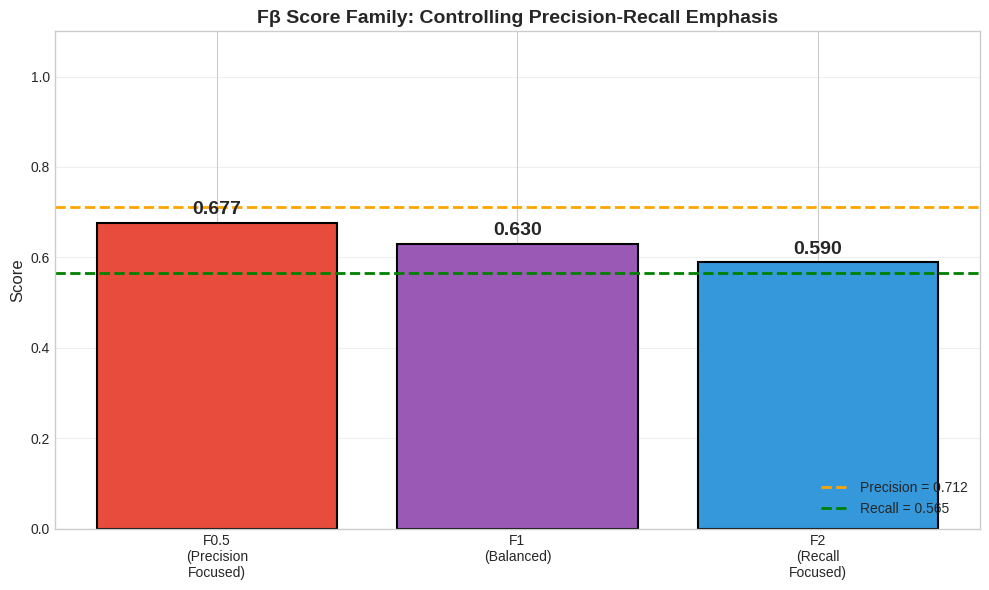

In [27]:
# Visualize Fβ scores
fig, ax = plt.subplots(figsize=(10, 6))

scores = [f05, f1, f2]
labels = ['F0.5\n(Precision\nFocused)', 'F1\n(Balanced)', 'F2\n(Recall\nFocused)']
colors = ['#e74c3c', '#9b59b6', '#3498db']

bars = ax.bar(labels, scores, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add reference lines
ax.axhline(y=precision, color='orange', linestyle='--', linewidth=2, label=f'Precision = {precision:.3f}')
ax.axhline(y=recall, color='green', linestyle='--', linewidth=2, label=f'Recall = {recall:.3f}')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Fβ Score Family: Controlling Precision-Recall Emphasis', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5.5 Matthews Correlation Coefficient (MCC)

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Why MCC?

MCC is considered one of the **best single metrics** for binary classification because:
- Uses **all four** confusion matrix values (TP, TN, FP, FN)
- Works well with **imbalanced classes**
- Returns values between **-1 and +1** (like correlation)

### Formula

$$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

</div>

### Interpretation

| MCC Value | Meaning |
|-----------|---------|
| **+1** | Perfect prediction |
| **0** | Random prediction (no better than chance) |
| **-1** | Complete disagreement (inverse prediction) |

In [28]:
# Import MCC
from sklearn.metrics import matthews_corrcoef

# Calculate MCC
mcc = matthews_corrcoef(y_test, y_pred)

print("Matthews Correlation Coefficient (MCC)")
print("=" * 50)
print(f"\nMCC = {mcc:.4f}")

# Compare with accuracy on imbalanced data
print("\n📊 MCC vs Accuracy on Imbalanced Data:")
mcc_dumb = matthews_corrcoef(y_imbalanced_true, y_pred_dumb)
print(f"\n   'Always Negative' Model:")
print(f"     Accuracy: {acc_dumb:.2%} (looks great!)")
print(f"     MCC:      {mcc_dumb:.4f} (correctly shows it's useless!)")

print(f"\n   Our Smart Model:")
print(f"     Accuracy: {acc_smart:.2%}")
print(f"     MCC:      {matthews_corrcoef(y_imbalanced_true, y_pred_smart):.4f} (shows actual performance)")

Matthews Correlation Coefficient (MCC)

MCC = 0.4989

📊 MCC vs Accuracy on Imbalanced Data:

   'Always Negative' Model:
     Accuracy: 99.00% (looks great!)
     MCC:      0.0000 (correctly shows it's useless!)

   Our Smart Model:
     Accuracy: 99.20%
     MCC:      0.6350 (shows actual performance)


## 5.6 Cohen's Kappa: Agreement Beyond Chance

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### Definition

**Cohen's Kappa** measures how much better your model is than random chance.

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Where:
- $p_o$ = observed accuracy
- $p_e$ = expected accuracy by random chance

</div>

In [29]:
# Import Cohen's Kappa
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)

print("Cohen's Kappa")
print("=" * 50)
print(f"\nKappa = {kappa:.4f}")

# Interpretation
def interpret_kappa(k):
    if k < 0: return "Less than chance agreement"
    elif k < 0.20: return "Slight agreement"
    elif k < 0.40: return "Fair agreement"
    elif k < 0.60: return "Moderate agreement"
    elif k < 0.80: return "Substantial agreement"
    else: return "Almost perfect agreement"

print(f"Interpretation: {interpret_kappa(kappa)}")

Cohen's Kappa

Kappa = 0.4926
Interpretation: Moderate agreement


# Classification Metrics: A Complete Progressive Guide
## From Fundamentals to MLOps-Ready Evaluation

---

**Course:** CMPE 258 - Deep Learning (Spring 2026)  
**Level:** Beginner to Intermediate  
**Prerequisites:** Basic Python, familiarity with machine learning concepts

---

## Learning Roadmap

This notebook is organized into **10 progressive tasks**, each building on the previous one:

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **1** | Setup & The Classification Problem | ⭐ Beginner | ✅ |
| **2** | Confusion Matrix - Foundation of All Metrics | ⭐ Beginner | ✅ |
| **3** | Accuracy & Its Limitations | ⭐ Beginner | ✅ |
| **4** | Precision & Recall | ⭐ Beginner | ✅ |
| **5** | F1, F2, Fβ Scores | ⭐⭐ Intermediate | ✅ |
| **6** | ROC Curves & AUC | ⭐⭐ Intermediate | ✅ |
| **7** | Precision-Recall Curves | ⭐⭐ Intermediate | ✅ |
| **8** | Multi-class Classification Metrics | ⭐⭐ Intermediate | ✅ |
| **9** | Imbalanced Datasets & Advanced Metrics | ⭐⭐⭐ Advanced | ✅ |
| **10** | MLOps Pipeline Metrics & Best Practices | ⭐⭐⭐ Advanced | ✅ |

---

---

# Task 6: ROC Curves & AUC

---

## 6.1 Learning Objectives

By the end of this task, you will:
- Understand what ROC curves represent
- Learn the concepts of TPR and FPR
- Calculate and interpret AUC-ROC
- Know when ROC curves are most useful

---

## 6.2 What is an ROC Curve?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**ROC** stands for **Receiver Operating Characteristic**.

An ROC curve plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various classification thresholds.

- **X-axis**: False Positive Rate (FPR) = FP / (FP + TN)
- **Y-axis**: True Positive Rate (TPR) = TP / (TP + FN) = Recall

</div>

### Key Points

- Each point on the curve represents a different threshold
- The curve shows the trade-off between catching positives (TPR) and false alarms (FPR)
- A perfect classifier has a point at (0, 1) - 100% TPR, 0% FPR

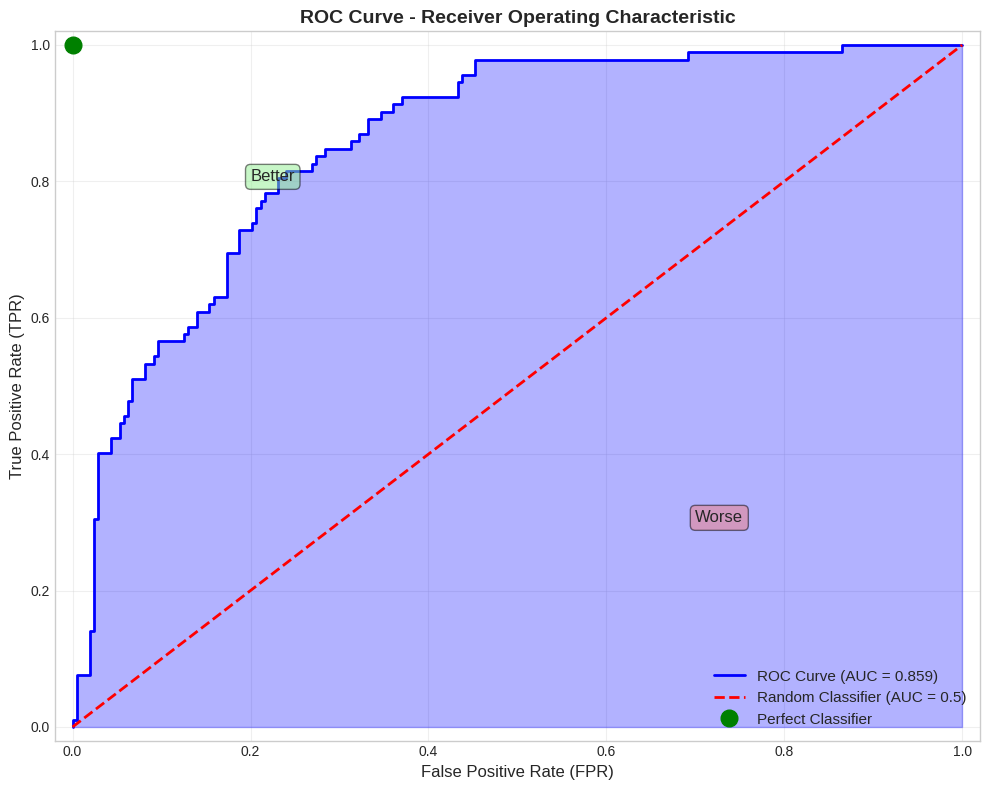


📊 AUC-ROC Score: 0.8593


In [30]:
# Import ROC functions
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')

# Mark perfect classifier point
ax.plot(0, 1, 'go', markersize=12, label='Perfect Classifier')

# Fill area under curve
ax.fill_between(fpr, tpr, alpha=0.3, color='blue')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('ROC Curve - Receiver Operating Characteristic', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)

# Add annotation
ax.annotate('Better', xy=(0.2, 0.8), fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.annotate('Worse', xy=(0.7, 0.3), fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n📊 AUC-ROC Score: {roc_auc:.4f}")

## 6.3 AUC-ROC: Area Under the Curve

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Interpretation of AUC

| AUC Value | Interpretation |
|-----------|----------------|
| **1.0** | Perfect classifier |
| **0.9 - 1.0** | Excellent |
| **0.8 - 0.9** | Good |
| **0.7 - 0.8** | Fair |
| **0.5 - 0.7** | Poor |
| **0.5** | Random (no discrimination) |
| **< 0.5** | Worse than random |

### Probabilistic Interpretation

AUC = Probability that a randomly chosen positive sample ranks higher than a randomly chosen negative sample.

</div>

## 6.4 Task 6 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

- ROC curve plots TPR vs FPR at all thresholds
- AUC-ROC summarizes the curve in a single number
- AUC = 0.5 means random, AUC = 1.0 means perfect
- Best for balanced datasets and comparing models

</div>

---

**Next:** Task 7 - Precision-Recall Curves

---

# Task 7: Precision-Recall Curves

---

## 7.1 What is a Precision-Recall Curve?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

A **Precision-Recall (PR) curve** plots Precision (y-axis) against Recall (x-axis) at various thresholds.

### When to Use PR Curves Instead of ROC

- **Imbalanced datasets** (rare positive class)
- When you care more about the positive class
- When false negatives are very costly

</div>

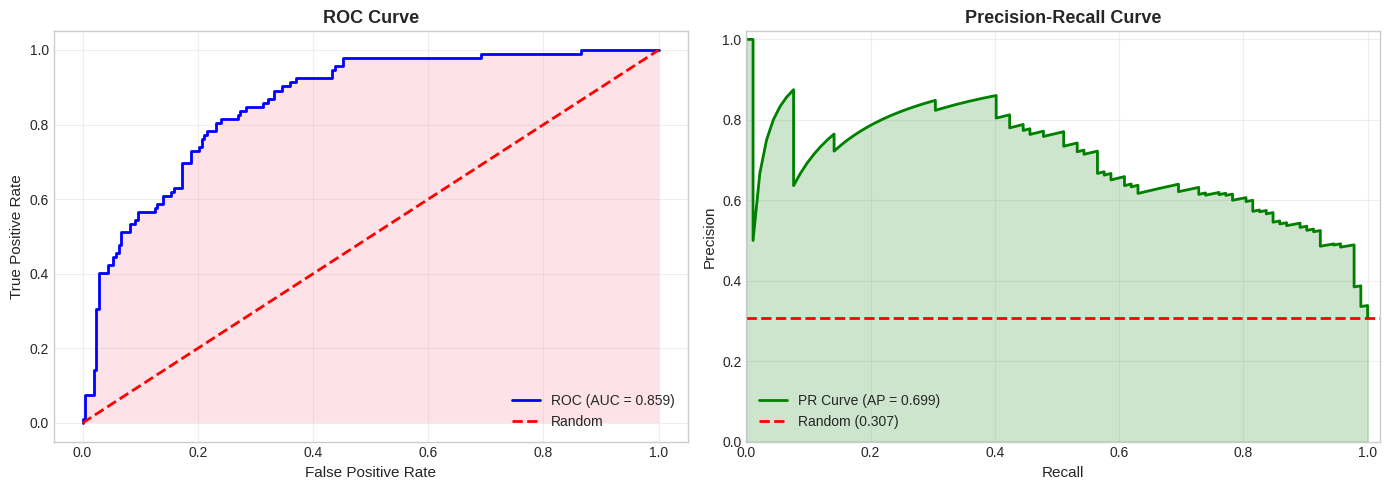

📊 AUC-ROC: 0.8593
📊 Average Precision (AUC-PR): 0.6995


In [31]:
# Import PR curve functions
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate PR curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# Plot both ROC and PR curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.2)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR Curve
axes[1].plot(recall_curve, precision_curve, 'g-', linewidth=2,
             label=f'PR Curve (AP = {avg_precision:.3f})')
# Baseline for PR curve is the proportion of positives
baseline = sum(y_test) / len(y_test)
axes[1].axhline(y=baseline, color='r', linestyle='--', linewidth=2,
                label=f'Random ({baseline:.3f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.2, color='green')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1.02])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print(f"📊 AUC-ROC: {roc_auc:.4f}")
print(f"📊 Average Precision (AUC-PR): {avg_precision:.4f}")

## 7.2 ROC vs PR Curves: When to Use Each

<div style="display: flex; gap: 20px; flex-wrap: wrap;">

<div style="flex: 1; min-width: 280px; background-color: #e3f2fd; padding: 20px; border-radius: 10px; border-left: 5px solid #2196f3;">

### Use ROC Curves When:

- Classes are **balanced**
- You care about **both classes** equally
- Comparing models in general
- TN is as important as TP

</div>

<div style="flex: 1; min-width: 280px; background-color: #e8f5e9; padding: 20px; border-radius: 10px; border-left: 5px solid #4caf50;">

### Use PR Curves When:

- Classes are **imbalanced**
- Positive class is **rare** (fraud, disease)
- You care more about **finding positives**
- False negatives are very costly

</div>

</div>

## 7.3 Task 7 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

- PR curves focus on the positive class
- Average Precision (AP) summarizes the PR curve
- PR curves are better for imbalanced data
- ROC can be overly optimistic with imbalance

</div>

---

**Next:** Task 8 - Multi-class Classification Metrics

---

# Task 8: Multi-class Classification Metrics

---

## 8.1 Extending Metrics to Multiple Classes

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Challenge

In multi-class classification, we have **3 or more classes**. How do we calculate precision, recall, and F1?

### Three Averaging Strategies

| Strategy | Description |
|----------|-------------|
| **Micro** | Calculate globally across all samples |
| **Macro** | Calculate per class, then average (unweighted) |
| **Weighted** | Calculate per class, then weighted average by support |

</div>

In [32]:
# Create a multi-class dataset using Iris
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report

# Load iris dataset (3 classes)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Split and train
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

model_mc = LogisticRegression(random_state=42, max_iter=1000)
model_mc.fit(X_train_mc, y_train_mc)
y_pred_mc = model_mc.predict(X_test_mc)

# Display classification report
print("Multi-class Classification Report (Iris Dataset)")
print("=" * 65)
print(f"\nClasses: {iris.target_names}")
print("\n" + classification_report(y_test_mc, y_pred_mc, target_names=iris.target_names))

Multi-class Classification Report (Iris Dataset)

Classes: ['setosa' 'versicolor' 'virginica']

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [33]:
# Compare averaging strategies
print("Averaging Strategies Comparison")
print("=" * 60)

for avg in ['micro', 'macro', 'weighted']:
    p = precision_score(y_test_mc, y_pred_mc, average=avg)
    r = recall_score(y_test_mc, y_pred_mc, average=avg)
    f = f1_score(y_test_mc, y_pred_mc, average=avg)
    print(f"\n{avg.upper():10s}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")

print("\n" + "=" * 60)
print("\n💡 Guidelines:")
print("   - MICRO: Good when all samples matter equally")
print("   - MACRO: Good when all classes matter equally")
print("   - WEIGHTED: Good when classes have different importance by size")

Averaging Strategies Comparison

MICRO     : Precision=0.933, Recall=0.933, F1=0.933

MACRO     : Precision=0.935, Recall=0.933, F1=0.933

WEIGHTED  : Precision=0.935, Recall=0.933, F1=0.933


💡 Guidelines:
   - MICRO: Good when all samples matter equally
   - MACRO: Good when all classes matter equally
   - WEIGHTED: Good when classes have different importance by size


## 8.2 Task 8 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

- Multi-class metrics need averaging strategies
- **Micro**: Global calculation (all samples equal)
- **Macro**: Per-class average (all classes equal)
- **Weighted**: Size-weighted average
- Use `classification_report` for comprehensive view

</div>

---

**Next:** Task 9 - Imbalanced Datasets & Advanced Metrics

---

# Task 9: Imbalanced Datasets & Advanced Metrics

---

## 9.1 The Imbalance Problem

<div style="background-color: #f8d7da; padding: 20px; border-radius: 10px; border-left: 5px solid #dc3545;">

### Real-World Imbalance Examples

| Domain | Positive Rate | Imbalance Ratio |
|--------|---------------|-----------------|
| Credit Card Fraud | 0.1% | 1:1000 |
| Disease Screening | 1% | 1:100 |
| Manufacturing Defects | 0.5% | 1:200 |
| Click-Through Rate | 2% | 1:50 |

Standard metrics like accuracy **fail** on imbalanced data!

</div>

## 9.2 Metrics That Work for Imbalanced Data

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Recommended Metrics

| Metric | Why It Works |
|--------|--------------|
| **Precision-Recall** | Focuses on positive class |
| **F1, F2 Score** | Balances precision and recall |
| **AUC-PR** | Better than AUC-ROC for imbalance |
| **MCC** | Uses all 4 confusion matrix values |
| **Balanced Accuracy** | Averages recall across classes |

### Metrics to AVOID

- **Accuracy**: Misleading (as shown earlier)
- **AUC-ROC**: Can be overly optimistic

</div>

In [34]:
# Comprehensive comparison on imbalanced data
print("Metrics Comparison: Imbalanced Data (99% vs 1%)")
print("=" * 65)

# Using our earlier imbalanced data
print(f"\nDataset: {len(y_imbalanced_true)} samples, {sum(y_imbalanced_true==1)} positive (1%)")

print(f"\n{'Metric':<25} {'Dumb Model':<15} {'Smart Model':<15}")
print("-" * 65)

# Calculate all metrics for both models
metrics_compare = [
    ('Accuracy', accuracy_score),
    ('Balanced Accuracy', balanced_accuracy_score),
    ('Precision', lambda y, p: precision_score(y, p, zero_division=0)),
    ('Recall', lambda y, p: recall_score(y, p, zero_division=0)),
    ('F1 Score', lambda y, p: f1_score(y, p, zero_division=0)),
    ('MCC', matthews_corrcoef),
]

for name, func in metrics_compare:
    dumb = func(y_imbalanced_true, y_pred_dumb)
    smart = func(y_imbalanced_true, y_pred_smart)
    highlight = " ⚠️" if name == "Accuracy" else ""
    print(f"{name:<25} {dumb:<15.4f} {smart:<15.4f}{highlight}")

print("=" * 65)
print("\n⚠️ Notice: Accuracy is MISLEADING! Other metrics reveal the truth.")

Metrics Comparison: Imbalanced Data (99% vs 1%)

Dataset: 10000 samples, 100 positive (1%)

Metric                    Dumb Model      Smart Model    
-----------------------------------------------------------------
Accuracy                  0.9900          0.9920          ⚠️
Balanced Accuracy         0.5000          0.8475         
Precision                 0.0000          0.5833         
Recall                    0.0000          0.7000         
F1 Score                  0.0000          0.6364         
MCC                       0.0000          0.6350         

⚠️ Notice: Accuracy is MISLEADING! Other metrics reveal the truth.


## 9.3 Task 9 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

- Imbalanced data requires special metrics
- **Avoid**: Accuracy, AUC-ROC alone
- **Use**: Precision, Recall, F1, MCC, AUC-PR, Balanced Accuracy
- Always report multiple metrics for imbalanced problems

</div>

---

**Next:** Task 10 - MLOps Pipeline Metrics & Best Practices

---

# Task 10: MLOps Pipeline Metrics & Best Practices

---

## 10.1 Metrics at Different ML Pipeline Stages

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The ML Lifecycle

```
Development → Validation → Testing → Production → Monitoring
```

Different stages require different metrics focus!

</div>

## 10.2 Metrics by Stage

| Stage | Primary Metrics | Purpose |
|-------|-----------------|---------|
| **Development** | Loss, Training accuracy | Model is learning |
| **Validation** | F1, AUC-ROC | Hyperparameter tuning |
| **Testing** | Full suite (P, R, F1, AUC) | Final evaluation |
| **Production** | Latency, throughput, F1 | Real-world performance |
| **Monitoring** | Drift metrics, error rates | Detect degradation |

## 10.3 Creating a Comprehensive Metrics Dashboard

In [35]:
def comprehensive_classification_report(y_true, y_pred, y_prob=None, model_name="Model"):
    """
    Generate a comprehensive classification metrics report.

    Parameters:
    -----------
    y_true : array-like - True labels
    y_pred : array-like - Predicted labels
    y_prob : array-like - Predicted probabilities (optional)
    model_name : str - Name of the model
    """
    print("=" * 70)
    print(f"COMPREHENSIVE CLASSIFICATION METRICS REPORT: {model_name}")
    print("=" * 70)

    # Confusion Matrix values
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Basic metrics
    print("\n📊 CONFUSION MATRIX")
    print("-" * 40)
    print(f"    TN={tn:4d}  |  FP={fp:4d}")
    print(f"    FN={fn:4d}  |  TP={tp:4d}")

    # Core metrics
    print("\n📈 CORE METRICS")
    print("-" * 40)
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall (Sensitivity)': recall_score(y_true, y_pred),
        'Specificity': tn / (tn + fp),
        'F1 Score': f1_score(y_true, y_pred),
        'F2 Score': fbeta_score(y_true, y_pred, beta=2),
        'MCC': matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
    }

    for name, value in metrics.items():
        bar = "█" * int(value * 20)
        print(f"  {name:22s}: {value:.4f} |{bar}|")

    # Probabilistic metrics (if probabilities provided)
    if y_prob is not None:
        print("\n📉 PROBABILISTIC METRICS")
        print("-" * 40)
        print(f"  {'AUC-ROC':22s}: {roc_auc_score(y_true, y_prob):.4f}")
        print(f"  {'Average Precision':22s}: {average_precision_score(y_true, y_prob):.4f}")

    print("\n" + "=" * 70)
    return metrics

# Generate report for our model
_ = comprehensive_classification_report(y_test, y_pred, y_prob, "Logistic Regression")

COMPREHENSIVE CLASSIFICATION METRICS REPORT: Logistic Regression

📊 CONFUSION MATRIX
----------------------------------------
    TN= 187  |  FP=  21
    FN=  40  |  TP=  52

📈 CORE METRICS
----------------------------------------
  Accuracy              : 0.7967 |███████████████|
  Balanced Accuracy     : 0.7321 |██████████████|
  Precision             : 0.7123 |██████████████|
  Recall (Sensitivity)  : 0.5652 |███████████|
  Specificity           : 0.8990 |█████████████████|
  F1 Score              : 0.6303 |████████████|
  F2 Score              : 0.5896 |███████████|
  MCC                   : 0.4989 |█████████|
  Cohen's Kappa         : 0.4926 |█████████|

📉 PROBABILISTIC METRICS
----------------------------------------
  AUC-ROC               : 0.8593
  Average Precision     : 0.6995



## 10.4 Best Practices: Choosing the Right Metric

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Decision Framework

1. **Check class balance first**
   - Balanced → Accuracy, F1, AUC-ROC OK
   - Imbalanced → Use PR-AUC, F1, MCC

2. **Understand error costs**
   - FP costly → Focus on Precision, F0.5
   - FN costly → Focus on Recall, F2

3. **Report multiple metrics**
   - Never rely on a single metric
   - Always include confusion matrix

4. **Consider the use case**
   - Medical: High recall (don't miss disease)
   - Spam: High precision (don't lose emails)
   - General: F1 as balanced metric

</div>

## 10.5 Quick Reference: Metric Cheat Sheet

| Scenario | Primary Metric | Secondary Metrics |
|----------|---------------|-------------------|
| Balanced data | F1, Accuracy | Precision, Recall |
| Imbalanced data | F1, MCC, PR-AUC | Precision, Recall |
| FN very costly | Recall, F2 | F1, Specificity |
| FP very costly | Precision, F0.5 | F1, Recall |
| Model comparison | AUC-ROC, F1 | MCC, Accuracy |
| Production monitoring | F1, Precision | Recall, Accuracy |

## 10.6 Task 10 Summary & Course Completion

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### What We've Accomplished in Task 10

1. ✅ Learned metrics for different ML pipeline stages
2. ✅ Built a comprehensive metrics dashboard
3. ✅ Established best practices for metric selection
4. ✅ Created a quick reference cheat sheet

</div>

---

# Congratulations! Course Complete!

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 30px; border-radius: 15px; color: white; text-align: center; margin: 20px 0;">

## You've Mastered Classification Metrics!

### Summary of All 10 Tasks

| Task | Topic | Key Learnings |
|------|-------|---------------|
| 1 | Setup | Classification types, dataset creation |
| 2 | Confusion Matrix | TP, TN, FP, FN foundations |
| 3 | Accuracy | When it works, when it fails |
| 4 | Precision & Recall | Trade-offs and use cases |
| 5 | F-scores | F1, F2, Fβ, MCC, Kappa |
| 6 | ROC Curves | AUC-ROC interpretation |
| 7 | PR Curves | When to use instead of ROC |
| 8 | Multi-class | Micro, macro, weighted averaging |
| 9 | Imbalanced Data | Metrics that work |
| 10 | MLOps | Pipeline metrics and best practices |

### Key Takeaways

1. **Never rely on accuracy alone** - especially with imbalanced data
2. **Understand your error costs** - FP vs FN implications
3. **Report multiple metrics** - confusion matrix + 2-3 key metrics
4. **Match metrics to your problem** - medical vs spam vs general

</div>

# Classification & Regression Metrics: A Complete Guide
## From Fundamentals to Production-Ready Evaluation

---

**Course:** CMPE 258 - Deep Learning (Spring 2026)  
**Level:** Beginner to Expert  
**Prerequisites:** Basic Python, familiarity with machine learning concepts

---

## Learning Roadmap

This notebook is organized into **18 progressive tasks** covering both classification and regression:

### Part 1: Classification Metrics (Tasks 1-13)

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **1** | Setup & The Classification Problem | ⭐ Beginner | ✅ |
| **2** | Confusion Matrix - Foundation of All Metrics | ⭐ Beginner | ✅ |
| **3** | Accuracy & Its Limitations | ⭐ Beginner | ✅ |
| **4** | Precision & Recall | ⭐ Beginner | ✅ |
| **5** | F1, F2, Fβ Scores | ⭐⭐ Intermediate | ✅ |
| **6** | ROC Curves & AUC | ⭐⭐ Intermediate | ✅ |
| **7** | Precision-Recall Curves | ⭐⭐ Intermediate | ✅ |
| **8** | Multi-class Classification Metrics | ⭐⭐ Intermediate | ✅ |
| **9** | Imbalanced Datasets & Advanced Metrics | ⭐⭐⭐ Advanced | ✅ |
| **10** | MLOps Pipeline Metrics & Best Practices | ⭐⭐⭐ Advanced | ✅ |
| **11** | Multi-label Classification Metrics | ⭐⭐⭐ Advanced | ✅ |
| **12** | Semi-supervised Classification Metrics | ⭐⭐⭐⭐ Expert | ✅ |
| **13** | Confidence Scores, Thresholds & Bucketization | ⭐⭐⭐⭐ Expert | ✅ |

### Part 2: Regression Metrics (Tasks 14-18)

| Task | Topic | Complexity | Status |
|------|-------|------------|--------|
| **14** | Introduction to Regression & Basic Metrics | ⭐ Beginner | ✅ |
| **15** | MAE, MSE, RMSE Deep Dive | ⭐ Beginner | ✅ |
| **16** | R² and Adjusted R² | ⭐⭐ Intermediate | ✅ |
| **17** | Advanced Regression Metrics (MAPE, SMAPE, etc.) | ⭐⭐ Intermediate | ✅ |
| **18** | Industry Best Practices & Decision Guide | ⭐⭐⭐ Advanced | ✅ |

---

---

# Task 11: Multi-label Classification Metrics

---

## 11.1 Learning Objectives

By the end of this task, you will:
- Understand the difference between multi-class and multi-label classification
- Learn specialized metrics for multi-label problems
- Implement Hamming Loss, Subset Accuracy, and label-based metrics
- Understand micro/macro/sample averaging for multi-label
- Apply these metrics to real-world multi-label scenarios

---

## 11.2 Multi-label vs Multi-class: Understanding the Difference

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Key Distinction

| Type | Description | Example |
|------|-------------|---------|
| **Multi-class** | One label per sample | Image is a Cat OR Dog OR Bird |
| **Multi-label** | Multiple labels per sample | Movie is Action AND Comedy AND Romance |

### Multi-label Characteristics
- Each sample can have **0, 1, or many** labels
- Labels are **not mutually exclusive**
- Output is a **binary vector** (one entry per possible label)

</div>

### Real-World Multi-label Examples

| Domain | Labels | Example |
|--------|--------|---------|
| **Movie Genres** | Action, Comedy, Drama, Horror, Romance | "Deadpool" → [Action, Comedy] |
| **Document Tags** | Sports, Politics, Tech, Business | Article → [Tech, Business] |
| **Medical Diagnosis** | Disease A, B, C, D | Patient → [Disease A, Disease C] |
| **Image Tags** | Person, Car, Tree, Building | Photo → [Person, Car, Tree] |
| **Music Genres** | Rock, Pop, Electronic, Jazz | Song → [Rock, Electronic] |

## 11.3 Creating a Multi-label Dataset

In [36]:
# Create a synthetic multi-label dataset
from sklearn.datasets import make_multilabel_classification
from sklearn.multioutput import MultiOutputClassifier

# Generate multi-label data (simulating movie genre classification)
X_ml, y_ml = make_multilabel_classification(
    n_samples=1000,
    n_features=20,
    n_classes=5,           # 5 possible genres
    n_labels=2,            # Average 2 labels per sample
    allow_unlabeled=False,
    random_state=42
)

# Define genre names for interpretability
genre_names = ['Action', 'Comedy', 'Drama', 'Horror', 'Romance']

# Split data
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.3, random_state=42
)

# Train a multi-label classifier
ml_classifier = MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000))
ml_classifier.fit(X_train_ml, y_train_ml)

# Predictions
y_pred_ml = ml_classifier.predict(X_test_ml)
y_prob_ml = np.array([est.predict_proba(X_test_ml)[:, 1] for est in ml_classifier.estimators_]).T

print("Multi-label Dataset Created!")
print("=" * 60)
print(f"Samples: {X_ml.shape[0]}, Features: {X_ml.shape[1]}, Labels: {y_ml.shape[1]}")
print(f"\nGenres: {genre_names}")
print(f"\nExample - First 5 test samples (actual):")
for i in range(5):
    labels = [genre_names[j] for j in range(5) if y_test_ml[i, j] == 1]
    print(f"  Movie {i+1}: {labels if labels else ['None']}")

Multi-label Dataset Created!
Samples: 1000, Features: 20, Labels: 5

Genres: ['Action', 'Comedy', 'Drama', 'Horror', 'Romance']

Example - First 5 test samples (actual):
  Movie 1: ['Horror']
  Movie 2: ['Drama']
  Movie 3: ['Comedy', 'Horror']
  Movie 4: ['Comedy', 'Horror']
  Movie 5: ['Action', 'Comedy', 'Drama', 'Horror']


## 11.4 Multi-label Metrics Overview

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Categories of Multi-label Metrics

**1. Example-based Metrics** (per sample, then average)
- Subset Accuracy (Exact Match)
- Hamming Loss
- Example-based Precision, Recall, F1

**2. Label-based Metrics** (per label, then aggregate)
- Micro-averaged Precision, Recall, F1
- Macro-averaged Precision, Recall, F1

**3. Ranking Metrics** (for probabilistic predictions)
- Label Ranking Average Precision (LRAP)
- Coverage Error
- Ranking Loss

</div>

## 11.5 Hamming Loss: Label-Level Error Rate

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### Definition

**Hamming Loss** measures the fraction of labels that are incorrectly predicted.

$$\text{Hamming Loss} = \frac{1}{n \cdot L} \sum_{i=1}^{n} \sum_{j=1}^{L} \mathbb{1}(y_{ij} \neq \hat{y}_{ij})$$

Where:
- $n$ = number of samples
- $L$ = number of labels
- $\mathbb{1}$ = indicator function (1 if true, 0 otherwise)

### Interpretation
- Range: 0 to 1
- **Lower is better** (0 = perfect)
- Measures average label prediction error

</div>

In [37]:
# Import multi-label metrics
from sklearn.metrics import (
    hamming_loss,
    accuracy_score as subset_accuracy,
    jaccard_score,
    label_ranking_average_precision_score,
    coverage_error,
    label_ranking_loss
)

# Calculate Hamming Loss
h_loss = hamming_loss(y_test_ml, y_pred_ml)

print("Hamming Loss Calculation")
print("=" * 60)
print(f"\nHamming Loss: {h_loss:.4f}")
print(f"\nInterpretation: On average, {h_loss*100:.2f}% of labels are incorrectly predicted.")
print(f"Equivalently: {(1-h_loss)*100:.2f}% of individual label predictions are correct.")

# Manual calculation for understanding
n_samples, n_labels = y_test_ml.shape
wrong_labels = np.sum(y_test_ml != y_pred_ml)
h_loss_manual = wrong_labels / (n_samples * n_labels)
print(f"\nManual verification: {wrong_labels} wrong out of {n_samples * n_labels} total = {h_loss_manual:.4f}")

Hamming Loss Calculation

Hamming Loss: 0.1720

Interpretation: On average, 17.20% of labels are incorrectly predicted.
Equivalently: 82.80% of individual label predictions are correct.

Manual verification: 258 wrong out of 1500 total = 0.1720


## 11.6 Subset Accuracy (Exact Match Ratio)

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Definition

**Subset Accuracy** (also called **Exact Match Ratio**) measures the percentage of samples where the predicted label set exactly matches the true label set.

$$\text{Subset Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}(y_i = \hat{y}_i)$$

### Characteristics
- Very **strict** metric
- Partial matches count as 0
- Good for when exact label set matters

</div>

In [38]:
# Calculate Subset Accuracy (Exact Match)
# Note: We need to compare row-by-row, not element-by-element
exact_matches = np.all(y_test_ml == y_pred_ml, axis=1)
subset_acc = np.mean(exact_matches)

print("Subset Accuracy (Exact Match Ratio)")
print("=" * 60)
print(f"\nSubset Accuracy: {subset_acc:.4f} ({subset_acc*100:.2f}%)")
print(f"\nInterpretation: {subset_acc*100:.2f}% of samples have ALL labels correctly predicted.")

# Compare with Hamming-based accuracy
print(f"\nComparison:")
print(f"  Subset Accuracy (strict):  {subset_acc:.4f}")
print(f"  Label-level Accuracy:      {1-h_loss:.4f}")
print(f"\n💡 Subset accuracy is much stricter - partial matches don't count!")

Subset Accuracy (Exact Match Ratio)

Subset Accuracy: 0.4100 (41.00%)

Interpretation: 41.00% of samples have ALL labels correctly predicted.

Comparison:
  Subset Accuracy (strict):  0.4100
  Label-level Accuracy:      0.8280

💡 Subset accuracy is much stricter - partial matches don't count!


## 11.7 Jaccard Score (Intersection over Union)

<div style="background-color: #e3f2fd; padding: 20px; border-radius: 10px; border-left: 5px solid #2196f3;">

### Definition

**Jaccard Score** (also called **Jaccard Similarity** or **IoU**) measures the similarity between predicted and actual label sets.

$$\text{Jaccard}(y, \hat{y}) = \frac{|y \cap \hat{y}|}{|y \cup \hat{y}|}$$

### Interpretation
- Range: 0 to 1
- **Higher is better**
- More forgiving than subset accuracy (partial credit for partial matches)

</div>

In [39]:
# Calculate Jaccard Score (multiple averaging methods)
jaccard_micro = jaccard_score(y_test_ml, y_pred_ml, average='micro')
jaccard_macro = jaccard_score(y_test_ml, y_pred_ml, average='macro')
jaccard_samples = jaccard_score(y_test_ml, y_pred_ml, average='samples')

print("Jaccard Score (Intersection over Union)")
print("=" * 60)
print(f"\nJaccard (micro):   {jaccard_micro:.4f}")
print(f"Jaccard (macro):   {jaccard_macro:.4f}")
print(f"Jaccard (samples): {jaccard_samples:.4f}")

# Per-label Jaccard
print(f"\nPer-label Jaccard scores:")
for i, genre in enumerate(genre_names):
    j_score = jaccard_score(y_test_ml[:, i], y_pred_ml[:, i])
    print(f"  {genre:12s}: {j_score:.4f}")

Jaccard Score (Intersection over Union)

Jaccard (micro):   0.6734
Jaccard (macro):   0.6194
Jaccard (samples): 0.7316

Per-label Jaccard scores:
  Action      : 0.5659
  Comedy      : 0.8165
  Drama       : 0.7150
  Horror      : 0.6839
  Romance     : 0.3158


## 11.8 Label-based Precision, Recall, F1

For multi-label problems, we calculate precision, recall, and F1 using different averaging strategies.

In [40]:
# Multi-label Precision, Recall, F1 with different averaging
print("Multi-label Classification Metrics")
print("=" * 70)

averaging_methods = ['micro', 'macro', 'weighted', 'samples']

print(f"\n{'Averaging':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 70)

for avg in averaging_methods:
    p = precision_score(y_test_ml, y_pred_ml, average=avg, zero_division=0)
    r = recall_score(y_test_ml, y_pred_ml, average=avg, zero_division=0)
    f = f1_score(y_test_ml, y_pred_ml, average=avg, zero_division=0)
    print(f"{avg:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

print("-" * 70)
print("\n💡 Averaging Methods:")
print("   - micro:    Global across all labels")
print("   - macro:    Average across labels (unweighted)")
print("   - weighted: Average weighted by support")
print("   - samples:  Average across samples")

Multi-label Classification Metrics

Averaging    Precision    Recall       F1 Score    
----------------------------------------------------------------------
micro        0.8326       0.7789       0.8048      
macro        0.7943       0.7178       0.7496      
weighted     0.8242       0.7789       0.7980      
samples      0.8533       0.8596       0.8197      
----------------------------------------------------------------------

💡 Averaging Methods:
   - micro:    Global across all labels
   - macro:    Average across labels (unweighted)
   - weighted: Average weighted by support
   - samples:  Average across samples


## 11.9 Ranking Metrics for Multi-label

<div style="background-color: #e2d6f8; padding: 20px; border-radius: 10px; border-left: 5px solid #6f42c1;">

### Why Ranking Metrics?

When models output **probabilities** rather than hard predictions, ranking metrics evaluate how well the model ranks relevant labels above irrelevant ones.

| Metric | Description |
|--------|-------------|
| **LRAP** | How well relevant labels are ranked |
| **Coverage Error** | How far we need to go to cover all true labels |
| **Ranking Loss** | Fraction of incorrectly ordered label pairs |

</div>

In [41]:
# Calculate ranking metrics using probability predictions
lrap = label_ranking_average_precision_score(y_test_ml, y_prob_ml)
cov_error = coverage_error(y_test_ml, y_prob_ml)
rank_loss = label_ranking_loss(y_test_ml, y_prob_ml)

print("Ranking Metrics (using probability predictions)")
print("=" * 60)
print(f"\nLabel Ranking Average Precision (LRAP): {lrap:.4f}")
print(f"  → Higher is better (1.0 = perfect ranking)")
print(f"\nCoverage Error: {cov_error:.4f}")
print(f"  → Lower is better (minimum = average number of true labels)")
print(f"\nRanking Loss: {rank_loss:.4f}")
print(f"  → Lower is better (0 = perfect ranking)")

Ranking Metrics (using probability predictions)

Label Ranking Average Precision (LRAP): 0.9696
  → Higher is better (1.0 = perfect ranking)

Coverage Error: 2.5233
  → Lower is better (minimum = average number of true labels)

Ranking Loss: 0.0558
  → Lower is better (0 = perfect ranking)


## 11.10 Comprehensive Multi-label Metrics Dashboard

In [42]:
def multilabel_metrics_report(y_true, y_pred, y_prob=None, label_names=None):
    """Generate a comprehensive multi-label metrics report."""
    n_labels = y_true.shape[1]
    if label_names is None:
        label_names = [f'Label_{i}' for i in range(n_labels)]

    print("=" * 70)
    print("COMPREHENSIVE MULTI-LABEL CLASSIFICATION REPORT")
    print("=" * 70)

    # Example-based metrics
    print("\n📊 EXAMPLE-BASED METRICS")
    print("-" * 50)
    print(f"  Hamming Loss:      {hamming_loss(y_true, y_pred):.4f} (lower is better)")
    print(f"  Subset Accuracy:   {np.mean(np.all(y_true == y_pred, axis=1)):.4f}")
    print(f"  Jaccard (samples): {jaccard_score(y_true, y_pred, average='samples'):.4f}")

    # Label-based metrics
    print("\n📈 LABEL-BASED METRICS")
    print("-" * 50)
    print(f"  F1 (micro):   {f1_score(y_true, y_pred, average='micro'):.4f}")
    print(f"  F1 (macro):   {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  F1 (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

    # Per-label performance
    print("\n📋 PER-LABEL PERFORMANCE")
    print("-" * 50)
    print(f"  {'Label':<12} {'Precision':<10} {'Recall':<10} {'F1':<10} {'Support':<10}")
    print("  " + "-" * 48)

    for i, name in enumerate(label_names):
        p = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
        r = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        s = np.sum(y_true[:, i])
        print(f"  {name:<12} {p:<10.4f} {r:<10.4f} {f:<10.4f} {s:<10}")

    # Ranking metrics (if probabilities provided)
    if y_prob is not None:
        print("\n📉 RANKING METRICS")
        print("-" * 50)
        print(f"  LRAP:          {label_ranking_average_precision_score(y_true, y_prob):.4f}")
        print(f"  Coverage:      {coverage_error(y_true, y_prob):.4f}")
        print(f"  Ranking Loss:  {label_ranking_loss(y_true, y_prob):.4f}")

    print("\n" + "=" * 70)

# Generate comprehensive report
multilabel_metrics_report(y_test_ml, y_pred_ml, y_prob_ml, genre_names)

COMPREHENSIVE MULTI-LABEL CLASSIFICATION REPORT

📊 EXAMPLE-BASED METRICS
--------------------------------------------------
  Hamming Loss:      0.1720 (lower is better)
  Subset Accuracy:   0.4100
  Jaccard (samples): 0.7316

📈 LABEL-BASED METRICS
--------------------------------------------------
  F1 (micro):   0.8048
  F1 (macro):   0.7496
  F1 (weighted): 0.7980

📋 PER-LABEL PERFORMANCE
--------------------------------------------------
  Label        Precision  Recall     F1         Support   
  ------------------------------------------------
  Action       0.8022     0.6577     0.7228     111       
  Comedy       0.8812     0.9175     0.8990     194       
  Drama        0.8519     0.8166     0.8338     169       
  Horror       0.8207     0.8041     0.8123     148       
  Romance      0.6154     0.3934     0.4800     61        

📉 RANKING METRICS
--------------------------------------------------
  LRAP:          0.9696
  Coverage:      2.5233
  Ranking Loss:  0.0558



## 11.11 Task 11 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### What We've Accomplished

1. ✅ Distinguished multi-label from multi-class classification
2. ✅ Learned Hamming Loss for label-level errors
3. ✅ Learned Subset Accuracy for exact matches
4. ✅ Learned Jaccard Score for set similarity
5. ✅ Applied precision/recall/F1 with various averaging
6. ✅ Explored ranking metrics (LRAP, Coverage, Ranking Loss)

### Key Metrics Cheat Sheet

| Metric | Best Value | Use When |
|--------|------------|----------|
| **Hamming Loss** | 0 | Label-level error matters |
| **Subset Accuracy** | 1 | Exact match required |
| **Jaccard** | 1 | Partial credit for partial matches |
| **LRAP** | 1 | Ranking quality matters |

</div>

---

**Next:** Task 12 - Semi-supervised Classification Metrics

---

# Task 12: Semi-supervised Classification Metrics

---

## 12.1 Learning Objectives

By the end of this task, you will:
- Understand semi-supervised learning and its evaluation challenges
- Learn metrics specific to semi-supervised classification
- Understand pseudo-label quality assessment
- Evaluate model performance on labeled vs unlabeled data
- Apply transductive and inductive evaluation strategies

---

## 12.2 What is Semi-supervised Learning?

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**Semi-supervised learning** uses a small amount of **labeled data** combined with a large amount of **unlabeled data** for training.

### The Setup

```
Total Data = Labeled Data (small) + Unlabeled Data (large)
                   ↓                        ↓
              Known labels            Unknown labels
              (used for training)     (used for learning structure)
```

### Why Semi-supervised?
- Labeled data is **expensive** to obtain
- Unlabeled data is **abundant** and cheap
- Can achieve better performance than supervised learning alone

</div>

### Real-World Applications

| Domain | Labeled | Unlabeled | Challenge |
|--------|---------|-----------|-----------|
| **Medical Imaging** | Expert-annotated scans | All patient scans | Annotation requires doctors |
| **Text Classification** | Human-labeled documents | Web crawl data | Manual labeling is slow |
| **Speech Recognition** | Transcribed audio | All audio recordings | Transcription is expensive |
| **Image Classification** | Manually tagged images | Internet images | Scale of manual tagging |

## 12.3 Evaluation Challenges in Semi-supervised Learning

<div style="background-color: #f8d7da; padding: 20px; border-radius: 10px; border-left: 5px solid #dc3545;">

### The Fundamental Challenge

Unlike supervised learning, we have **three** evaluation scenarios:

1. **Labeled Training Data** - Known labels, used for training
2. **Unlabeled Training Data** - No labels during training, may have held-out labels for evaluation
3. **Test Data** - Completely unseen data

### Key Questions to Answer

- How well does the model perform on **held-out labeled data**?
- How well does the model perform on the **unlabeled data** (transductive)?
- How well does the model **generalize** to new data (inductive)?
- How good are the **pseudo-labels** generated during training?

</div>

## 12.4 Simulating a Semi-supervised Scenario

In [43]:
# Simulate a semi-supervised learning scenario
np.random.seed(42)

# Create dataset
X_full, y_full = make_classification(
    n_samples=2000, n_features=20, n_informative=10,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

# Split into: labeled (10%), unlabeled (60%), test (30%)
# First split: train (70%) vs test (30%)
X_train_full, X_test_ss, y_train_full, y_test_ss = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

# Second split: labeled (small) vs unlabeled (large) within training
n_labeled = int(len(X_train_full) * 0.15)  # Only 15% of training data is labeled
indices = np.random.permutation(len(X_train_full))
labeled_idx = indices[:n_labeled]
unlabeled_idx = indices[n_labeled:]

X_labeled = X_train_full[labeled_idx]
y_labeled = y_train_full[labeled_idx]
X_unlabeled = X_train_full[unlabeled_idx]
y_unlabeled_true = y_train_full[unlabeled_idx]  # Hidden during training, used for evaluation

print("Semi-supervised Learning Setup")
print("=" * 60)
print(f"\n📁 Data Split:")
print(f"   Labeled training:   {len(X_labeled):4d} samples ({len(X_labeled)/len(X_full)*100:.1f}%)")
print(f"   Unlabeled training: {len(X_unlabeled):4d} samples ({len(X_unlabeled)/len(X_full)*100:.1f}%)")
print(f"   Test set:           {len(X_test_ss):4d} samples ({len(X_test_ss)/len(X_full)*100:.1f}%)")
print(f"\n   Total:              {len(X_full):4d} samples")

Semi-supervised Learning Setup

📁 Data Split:
   Labeled training:    210 samples (10.5%)
   Unlabeled training: 1190 samples (59.5%)
   Test set:            600 samples (30.0%)

   Total:              2000 samples


## 12.5 Self-Training: A Simple Semi-supervised Method

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### How Self-Training Works

1. Train on labeled data
2. Predict labels for unlabeled data (**pseudo-labels**)
3. Add confident pseudo-labeled samples to training set
4. Retrain and repeat

### The Key Question: How good are the pseudo-labels?

</div>

In [44]:
# Implement a simple self-training approach
from sklearn.base import clone

def self_training(model, X_labeled, y_labeled, X_unlabeled,
                  confidence_threshold=0.9, max_iterations=5):
    """
    Simple self-training semi-supervised learning.

    Returns:
    - Trained model
    - Pseudo-labels for unlabeled data
    - Confidence scores
    - History of metrics per iteration
    """
    model = clone(model)
    X_train = X_labeled.copy()
    y_train = y_labeled.copy()
    X_pool = X_unlabeled.copy()

    history = []

    for iteration in range(max_iterations):
        # Train on current labeled + pseudo-labeled data
        model.fit(X_train, y_train)

        if len(X_pool) == 0:
            break

        # Predict on remaining unlabeled data
        probs = model.predict_proba(X_pool)
        max_probs = np.max(probs, axis=1)
        predictions = np.argmax(probs, axis=1)

        # Select confident predictions
        confident_mask = max_probs >= confidence_threshold
        n_confident = np.sum(confident_mask)

        history.append({
            'iteration': iteration + 1,
            'n_training': len(X_train),
            'n_pool': len(X_pool),
            'n_confident': n_confident,
            'avg_confidence': np.mean(max_probs)
        })

        if n_confident == 0:
            break

        # Add confident samples to training set
        X_train = np.vstack([X_train, X_pool[confident_mask]])
        y_train = np.concatenate([y_train, predictions[confident_mask]])
        X_pool = X_pool[~confident_mask]

    # Final predictions for all unlabeled data
    final_probs = model.predict_proba(X_unlabeled)
    pseudo_labels = np.argmax(final_probs, axis=1)
    confidences = np.max(final_probs, axis=1)

    return model, pseudo_labels, confidences, history

# Run self-training
base_model = LogisticRegression(random_state=42, max_iter=1000)
ss_model, pseudo_labels, confidences, training_history = self_training(
    base_model, X_labeled, y_labeled, X_unlabeled,
    confidence_threshold=0.85, max_iterations=10
)

print("Self-Training Progress")
print("=" * 70)
print(f"\n{'Iter':<6} {'Training':<12} {'Pool':<12} {'Confident':<12} {'Avg Conf':<12}")
print("-" * 70)
for h in training_history:
    print(f"{h['iteration']:<6} {h['n_training']:<12} {h['n_pool']:<12} {h['n_confident']:<12} {h['avg_confidence']:<12.4f}")

Self-Training Progress

Iter   Training     Pool         Confident    Avg Conf    
----------------------------------------------------------------------
1      210          1190         1004         0.9381      
2      1214         186          62           0.7753      
3      1276         124          19           0.7289      
4      1295         105          5            0.7071      
5      1300         100          5            0.7047      
6      1305         95           4            0.7031      
7      1309         91           3            0.6994      
8      1312         88           0            0.6967      


## 12.6 Pseudo-label Quality Metrics

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Key Metrics for Pseudo-labels

| Metric | Description | Ideal |
|--------|-------------|-------|
| **Pseudo-label Accuracy** | How many pseudo-labels are correct | Higher |
| **Coverage** | What percentage of unlabeled data got pseudo-labels | Higher |
| **Confidence Calibration** | Do confidence scores reflect actual accuracy | Well-calibrated |
| **Label Distribution** | Are pseudo-labels distributed like true labels | Similar |

</div>

In [45]:
# Evaluate pseudo-label quality (using held-out true labels)
print("Pseudo-label Quality Assessment")
print("=" * 70)

# 1. Pseudo-label Accuracy
pl_accuracy = accuracy_score(y_unlabeled_true, pseudo_labels)
print(f"\n📊 PSEUDO-LABEL ACCURACY")
print(f"   Accuracy: {pl_accuracy:.4f} ({pl_accuracy*100:.2f}%)")

# 2. Per-class pseudo-label accuracy
print(f"\n📋 PER-CLASS PSEUDO-LABEL PERFORMANCE")
print(f"   {'Class':<10} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("   " + "-" * 42)
for c in range(3):
    p = precision_score(y_unlabeled_true == c, pseudo_labels == c)
    r = recall_score(y_unlabeled_true == c, pseudo_labels == c)
    f = f1_score(y_unlabeled_true == c, pseudo_labels == c)
    print(f"   Class {c:<4} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

# 3. Confidence analysis
print(f"\n📈 CONFIDENCE ANALYSIS")
print(f"   Mean confidence: {np.mean(confidences):.4f}")
print(f"   Min confidence:  {np.min(confidences):.4f}")
print(f"   Max confidence:  {np.max(confidences):.4f}")

# 4. Accuracy by confidence bucket
print(f"\n📉 ACCURACY BY CONFIDENCE BUCKET")
buckets = [(0.0, 0.5), (0.5, 0.7), (0.7, 0.85), (0.85, 0.95), (0.95, 1.0)]
print(f"   {'Confidence':<15} {'Count':<10} {'Accuracy':<10}")
print("   " + "-" * 35)
for low, high in buckets:
    mask = (confidences >= low) & (confidences < high)
    if np.sum(mask) > 0:
        acc = accuracy_score(y_unlabeled_true[mask], pseudo_labels[mask])
        print(f"   {low:.2f} - {high:.2f}{'':>5} {np.sum(mask):<10} {acc:<10.4f}")

print("\n💡 Insight: Higher confidence should correlate with higher accuracy!")

Pseudo-label Quality Assessment

📊 PSEUDO-LABEL ACCURACY
   Accuracy: 0.9387 (93.87%)

📋 PER-CLASS PSEUDO-LABEL PERFORMANCE
   Class      Precision    Recall       F1          
   ------------------------------------------
   Class 0    0.9268       0.9039       0.9152      
   Class 1    0.9438       0.9650       0.9543      
   Class 2    0.9455       0.9479       0.9467      

📈 CONFIDENCE ANALYSIS
   Mean confidence: 0.9688
   Min confidence:  0.4471
   Max confidence:  1.0000

📉 ACCURACY BY CONFIDENCE BUCKET
   Confidence      Count      Accuracy  
   -----------------------------------
   0.00 - 0.50      2          0.5000    
   0.50 - 0.70      35         0.5714    
   0.70 - 0.85      53         0.7547    
   0.85 - 0.95      70         0.7571    
   0.95 - 1.00      1030       0.9738    

💡 Insight: Higher confidence should correlate with higher accuracy!


## 12.7 Transductive vs Inductive Evaluation

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### Two Types of Evaluation

| Type | Evaluates On | Question Answered |
|------|--------------|-------------------|
| **Transductive** | Unlabeled training data | "How well did we label the unlabeled data?" |
| **Inductive** | Held-out test data | "How well does the model generalize?" |

### Both Matter!
- Transductive shows learning from structure
- Inductive shows generalization ability

</div>

In [46]:
# Compare supervised vs semi-supervised performance
print("Supervised vs Semi-supervised Performance Comparison")
print("=" * 70)

# Train supervised model (only on labeled data)
supervised_model = LogisticRegression(random_state=42, max_iter=1000)
supervised_model.fit(X_labeled, y_labeled)

# Predictions
y_pred_supervised_test = supervised_model.predict(X_test_ss)
y_pred_supervised_unlabeled = supervised_model.predict(X_unlabeled)

y_pred_semisup_test = ss_model.predict(X_test_ss)
y_pred_semisup_unlabeled = ss_model.predict(X_unlabeled)

print(f"\n{'Evaluation Set':<25} {'Supervised':<15} {'Semi-supervised':<15} {'Improvement':<12}")
print("-" * 70)

# Transductive (unlabeled data)
sup_trans = accuracy_score(y_unlabeled_true, y_pred_supervised_unlabeled)
ss_trans = accuracy_score(y_unlabeled_true, y_pred_semisup_unlabeled)
print(f"{'Transductive (unlabeled)':<25} {sup_trans:<15.4f} {ss_trans:<15.4f} {(ss_trans-sup_trans)*100:+.2f}%")

# Inductive (test data)
sup_ind = accuracy_score(y_test_ss, y_pred_supervised_test)
ss_ind = accuracy_score(y_test_ss, y_pred_semisup_test)
print(f"{'Inductive (test)':<25} {sup_ind:<15.4f} {ss_ind:<15.4f} {(ss_ind-sup_ind)*100:+.2f}%")

# Labeled data (sanity check)
sup_lab = accuracy_score(y_labeled, supervised_model.predict(X_labeled))
ss_lab = accuracy_score(y_labeled, ss_model.predict(X_labeled))
print(f"{'Labeled (train)':<25} {sup_lab:<15.4f} {ss_lab:<15.4f} {(ss_lab-sup_lab)*100:+.2f}%")

print("=" * 70)
print("\n💡 Semi-supervised learning leverages unlabeled data to improve performance!")

Supervised vs Semi-supervised Performance Comparison

Evaluation Set            Supervised      Semi-supervised Improvement 
----------------------------------------------------------------------
Transductive (unlabeled)  0.9336          0.9387          +0.50%
Inductive (test)          0.9200          0.9200          +0.00%
Labeled (train)           0.9476          0.9667          +1.90%

💡 Semi-supervised learning leverages unlabeled data to improve performance!


## 12.8 Task 12 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### What We've Accomplished

1. ✅ Understood semi-supervised learning fundamentals
2. ✅ Implemented self-training with pseudo-labeling
3. ✅ Learned pseudo-label quality assessment metrics
4. ✅ Differentiated transductive vs inductive evaluation
5. ✅ Compared supervised vs semi-supervised performance

### Key Metrics Cheat Sheet

| Metric | Description | Use When |
|--------|-------------|----------|
| **Pseudo-label Accuracy** | Correctness of generated labels | Evaluating learning quality |
| **Confidence Calibration** | Correlation between confidence and accuracy | Assessing reliability |
| **Transductive Accuracy** | Performance on unlabeled training data | Evaluating structure learning |
| **Inductive Accuracy** | Performance on held-out test data | Evaluating generalization |

### When to Use Semi-supervised Learning

- Labeled data is scarce/expensive
- Large amounts of unlabeled data available
- Data has underlying cluster structure
- Performance gains outweigh complexity

</div>

---

**Next:** Task 13 - Confidence Scores, Thresholds & Bucketization

---

# Task 13: Confidence Scores, Thresholds & Bucketization

---

## 13.1 Learning Objectives

By the end of this task, you will:
- Understand what classifier confidence scores represent
- Learn how to calibrate confidence scores
- Master threshold selection for different business objectives
- Learn confidence bucketization strategies
- Apply these techniques to production classification systems

---

## 13.2 What Are Confidence Scores?

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**Confidence scores** (probability estimates) represent how certain a classifier is about its prediction.

```
Input → Model → [Class A: 0.15, Class B: 0.75, Class C: 0.10]
                         ↓
                 Prediction: Class B (75% confident)
```

### Key Insight

**Confidence ≠ Correctness**

A model can be:
- **Confident AND correct** (ideal) ✅
- **Confident BUT wrong** (overconfident) ⚠️
- **Uncertain AND wrong** (expected uncertainty)
- **Uncertain BUT correct** (lucky guess)

</div>

### Sources of Confidence Scores

| Model Type | How Confidence is Computed |
|------------|---------------------------|
| **Logistic Regression** | Sigmoid/Softmax output |
| **Random Forest** | Vote proportion across trees |
| **SVM** | Platt scaling (post-hoc) |
| **Neural Networks** | Softmax output |
| **Gradient Boosting** | Probability estimation |

In [47]:
# Exploring Classifier Confidence Scores
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

# Create a binary classification dataset
np.random.seed(42)
X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=10,
    n_redundant=5, n_classes=2, flip_y=0.1, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train different models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Get predictions and probabilities
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1
    y_pred = model.predict(X_test)
    predictions[name] = {'prob': y_prob, 'pred': y_pred}

# Examine confidence distribution
print("Confidence Score Distribution Analysis")
print("=" * 70)

for name, preds in predictions.items():
    probs = preds['prob']
    print(f"\n📊 {name}")
    print(f"   Mean confidence:   {np.mean(np.maximum(probs, 1-probs)):.4f}")
    print(f"   Median confidence: {np.median(np.maximum(probs, 1-probs)):.4f}")
    print(f"   Std confidence:    {np.std(probs):.4f}")
    print(f"   Range:             [{np.min(probs):.4f}, {np.max(probs):.4f}]")

Confidence Score Distribution Analysis

📊 Logistic Regression
   Mean confidence:   0.7894
   Median confidence: 0.8029
   Std confidence:    0.3234
   Range:             [0.0006, 0.9942]

📊 Random Forest
   Mean confidence:   0.7801
   Median confidence: 0.8000
   Std confidence:    0.3117
   Range:             [0.0000, 1.0000]

📊 Gradient Boosting
   Mean confidence:   0.8295
   Median confidence: 0.8749
   Std confidence:    0.3572
   Range:             [0.0088, 0.9875]


## 13.3 Confidence Calibration

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### What is Calibration?

A classifier is **well-calibrated** when its confidence scores match the actual probability of being correct.

**Perfect calibration:** When a model says "80% confident", it should be correct ~80% of the time.

### Calibration Curve (Reliability Diagram)

Plots **predicted probability** (X-axis) vs **actual frequency of positives** (Y-axis).

- **Perfect calibration:** Diagonal line
- **Above diagonal:** Underconfident (reality > prediction)
- **Below diagonal:** Overconfident (prediction > reality)

### Expected Calibration Error (ECE)

$$ECE = \sum_{m=1}^{M} \frac{|B_m|}{n} |acc(B_m) - conf(B_m)|$$

Where $B_m$ is the $m$-th confidence bin.

</div>

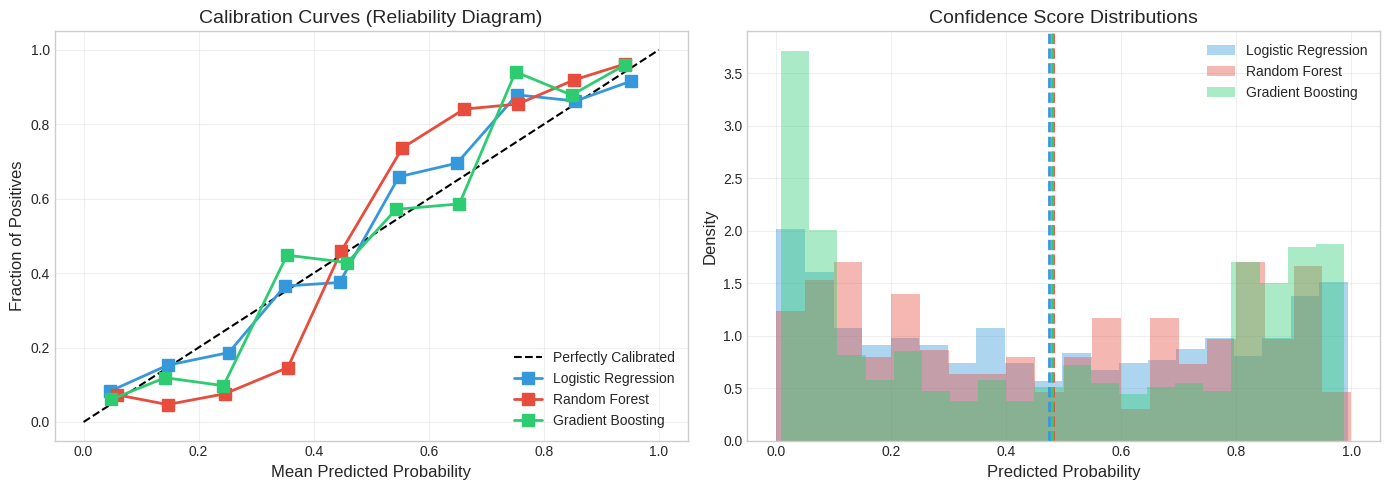


Expected Calibration Error (ECE)
Model                     ECE        Quality
--------------------------------------------------
Logistic Regression       0.0491     Excellent
Random Forest             0.0972     Good
Gradient Boosting         0.0447     Excellent


In [48]:
# Visualize calibration curves for different models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Calibration curves
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, preds), color in zip(predictions.items(), colors):
    prob_true, prob_pred = calibration_curve(y_test, preds['prob'], n_bins=10)
    ax1.plot(prob_pred, prob_true, 's-', color=color, label=name, linewidth=2, markersize=8)

ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
ax1.set_ylabel('Fraction of Positives', fontsize=12)
ax1.set_title('Calibration Curves (Reliability Diagram)', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Right plot: Confidence distribution histograms
ax2 = axes[1]
for (name, preds), color in zip(predictions.items(), colors):
    ax2.hist(preds['prob'], bins=20, alpha=0.4, color=color, label=name, density=True)
    ax2.axvline(np.mean(preds['prob']), color=color, linestyle='--', linewidth=2)

ax2.set_xlabel('Predicted Probability', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Confidence Score Distributions', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate Expected Calibration Error (ECE)
def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i + 1])
        if np.sum(mask) > 0:
            bin_accuracy = np.mean(y_true[mask])
            bin_confidence = np.mean(y_prob[mask])
            bin_weight = np.sum(mask) / len(y_true)
            ece += bin_weight * np.abs(bin_accuracy - bin_confidence)

    return ece

print("\nExpected Calibration Error (ECE)")
print("=" * 50)
print(f"{'Model':<25} {'ECE':<10} {'Quality'}")
print("-" * 50)
for name, preds in predictions.items():
    ece = calculate_ece(y_test, preds['prob'])
    quality = "Excellent" if ece < 0.05 else "Good" if ece < 0.1 else "Needs Calibration"
    print(f"{name:<25} {ece:<10.4f} {quality}")

## 13.4 Threshold Selection for Business Objectives

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### The Default Threshold Problem

Most classifiers use **threshold = 0.5** by default:
- If probability > 0.5 → Predict positive
- If probability ≤ 0.5 → Predict negative

**But 0.5 is rarely the optimal threshold!**

### Choosing Thresholds for Different Goals

| Business Goal | Optimize For | Threshold Direction |
|---------------|--------------|---------------------|
| **Minimize false alarms** | High Precision | Increase threshold |
| **Catch all positives** | High Recall | Decrease threshold |
| **Balance both** | F1 Score | Find optimal via analysis |
| **Minimize costs** | Custom cost function | Based on cost ratio |

</div>

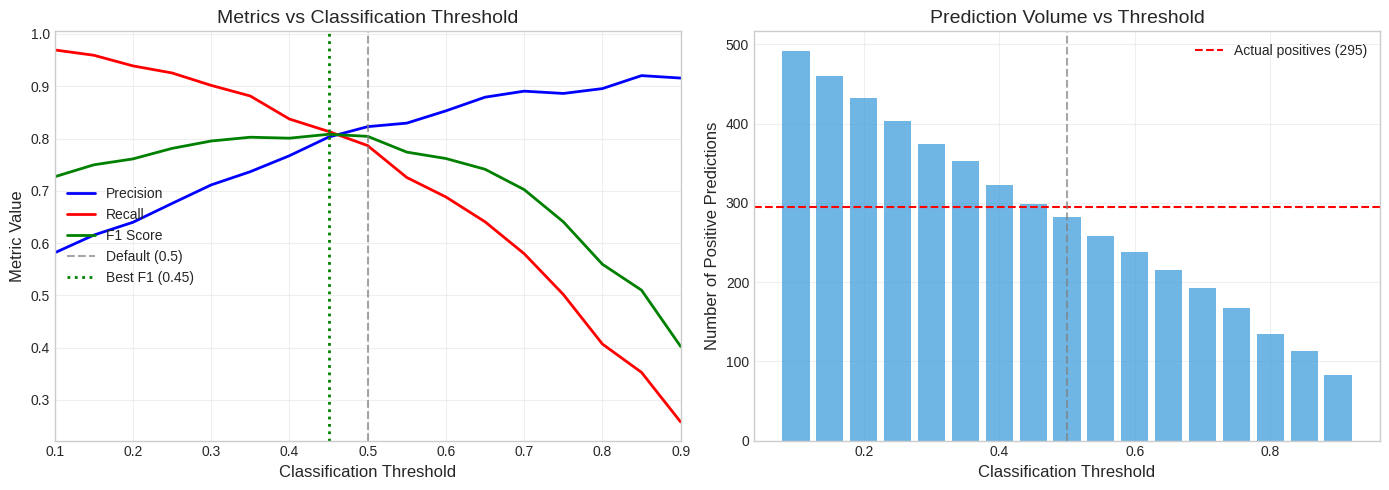


Threshold Analysis Table
Threshold    Precision    Recall       F1           Accuracy    
---------------------------------------------------------------------------
0.10         0.5813       0.9695       0.7268       0.6417      
0.20         0.6397       0.9390       0.7610       0.7100      
0.30         0.7112       0.9017       0.7952       0.7717      
0.40         0.7671       0.8373       0.8006       0.7950      
0.50         0.8227       0.7864       0.8042       0.8117      
0.60         0.8529       0.6881       0.7617       0.7883      
0.70         0.8906       0.5797       0.7023       0.7583      
0.80         0.8955       0.4068       0.5594       0.6850      
0.90         0.9157       0.2576       0.4021       0.6233      


In [49]:
# Threshold Analysis: How metrics change with threshold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Use Logistic Regression for this analysis
y_prob_lr = predictions['Logistic Regression']['prob']

# Analyze different thresholds
thresholds = np.arange(0.1, 0.95, 0.05)
metrics_by_threshold = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_lr >= thresh).astype(int)

    # Calculate metrics (handle edge cases)
    try:
        prec = precision_score(y_test, y_pred_thresh, zero_division=0)
        rec = recall_score(y_test, y_pred_thresh, zero_division=0)
        f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
        acc = accuracy_score(y_test, y_pred_thresh)
    except:
        prec, rec, f1, acc = 0, 0, 0, 0

    metrics_by_threshold.append({
        'threshold': thresh,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'accuracy': acc,
        'n_positive_pred': np.sum(y_pred_thresh)
    })

# Plot metrics vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision-Recall-F1 vs Threshold
ax1 = axes[0]
threshs = [m['threshold'] for m in metrics_by_threshold]
ax1.plot(threshs, [m['precision'] for m in metrics_by_threshold], 'b-', label='Precision', linewidth=2)
ax1.plot(threshs, [m['recall'] for m in metrics_by_threshold], 'r-', label='Recall', linewidth=2)
ax1.plot(threshs, [m['f1'] for m in metrics_by_threshold], 'g-', label='F1 Score', linewidth=2)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')

# Find optimal thresholds
best_f1_idx = np.argmax([m['f1'] for m in metrics_by_threshold])
best_f1_thresh = metrics_by_threshold[best_f1_idx]['threshold']
ax1.axvline(best_f1_thresh, color='green', linestyle=':', linewidth=2, label=f'Best F1 ({best_f1_thresh:.2f})')

ax1.set_xlabel('Classification Threshold', fontsize=12)
ax1.set_ylabel('Metric Value', fontsize=12)
ax1.set_title('Metrics vs Classification Threshold', fontsize=14)
ax1.legend(loc='center left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0.1, 0.9])

# Right: Number of positive predictions vs Threshold
ax2 = axes[1]
ax2.bar(threshs, [m['n_positive_pred'] for m in metrics_by_threshold], width=0.04, color='#3498db', alpha=0.7)
ax2.axhline(np.sum(y_test), color='red', linestyle='--', label=f'Actual positives ({np.sum(y_test)})')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax2.set_xlabel('Classification Threshold', fontsize=12)
ax2.set_ylabel('Number of Positive Predictions', fontsize=12)
ax2.set_title('Prediction Volume vs Threshold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print threshold analysis table
print("\nThreshold Analysis Table")
print("=" * 75)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-" * 75)
for m in metrics_by_threshold[::2]:  # Every other for brevity
    print(f"{m['threshold']:<12.2f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['accuracy']:<12.4f}")

## 13.5 Optimal Threshold Finding Methods

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Common Methods for Finding Optimal Thresholds

| Method | Best For | How It Works |
|--------|----------|--------------|
| **Youden's J** | Balanced sensitivity/specificity | Maximizes TPR - FPR |
| **F1 Optimal** | Balanced precision/recall | Maximizes F1 score |
| **Cost-based** | Business constraints | Minimizes FP_cost × FP + FN_cost × FN |
| **Target Precision** | When false alarms are costly | Find threshold for target precision |
| **Target Recall** | When missing positives is costly | Find threshold for target recall |

</div>

In [50]:
# Optimal Threshold Finding Methods
from sklearn.metrics import roc_curve, precision_recall_curve

def find_optimal_thresholds(y_true, y_prob):
    """Find optimal thresholds using different methods."""
    results = {}

    # Method 1: Youden's J statistic (ROC-based)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_j_idx = np.argmax(j_scores)
    results['youden_j'] = {
        'threshold': roc_thresholds[best_j_idx],
        'score': j_scores[best_j_idx],
        'description': "Maximizes TPR - FPR (sensitivity + specificity - 1)"
    }

    # Method 2: F1 Optimal
    precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precision_arr[:-1] * recall_arr[:-1]) / (precision_arr[:-1] + recall_arr[:-1] + 1e-10)
    best_f1_idx = np.argmax(f1_scores)
    results['f1_optimal'] = {
        'threshold': pr_thresholds[best_f1_idx],
        'score': f1_scores[best_f1_idx],
        'description': "Maximizes F1 score (harmonic mean of precision and recall)"
    }

    # Method 3: Target Precision >= 0.9
    target_precision = 0.9
    valid_idx = np.where(precision_arr[:-1] >= target_precision)[0]
    if len(valid_idx) > 0:
        # Find highest recall while maintaining precision
        best_recall_idx = valid_idx[np.argmax(recall_arr[:-1][valid_idx])]
        results['target_precision_90'] = {
            'threshold': pr_thresholds[best_recall_idx],
            'score': precision_arr[best_recall_idx],
            'description': f"Achieves precision >= {target_precision} with max recall"
        }

    # Method 4: Target Recall >= 0.9
    target_recall = 0.9
    valid_idx = np.where(recall_arr[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        # Find highest precision while maintaining recall
        best_prec_idx = valid_idx[np.argmax(precision_arr[:-1][valid_idx])]
        results['target_recall_90'] = {
            'threshold': pr_thresholds[best_prec_idx],
            'score': recall_arr[best_prec_idx],
            'description': f"Achieves recall >= {target_recall} with max precision"
        }

    return results

# Find optimal thresholds for Logistic Regression
optimal_thresholds = find_optimal_thresholds(y_test, y_prob_lr)

print("Optimal Threshold Analysis")
print("=" * 70)
for method, info in optimal_thresholds.items():
    print(f"\n📊 {method.upper().replace('_', ' ')}")
    print(f"   Threshold: {info['threshold']:.4f}")
    print(f"   Score:     {info['score']:.4f}")
    print(f"   Strategy:  {info['description']}")

# Compare predictions at different optimal thresholds
print("\n" + "=" * 70)
print("Performance Comparison at Different Thresholds")
print("=" * 70)
print(f"{'Method':<25} {'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 70)

for method, info in optimal_thresholds.items():
    thresh = info['threshold']
    y_pred_opt = (y_prob_lr >= thresh).astype(int)
    p = precision_score(y_test, y_pred_opt, zero_division=0)
    r = recall_score(y_test, y_pred_opt, zero_division=0)
    f = f1_score(y_test, y_pred_opt, zero_division=0)
    print(f"{method:<25} {thresh:<12.4f} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Optimal Threshold Analysis

📊 YOUDEN J
   Threshold: 0.4505
   Score:     0.6234
   Strategy:  Maximizes TPR - FPR (sensitivity + specificity - 1)

📊 F1 OPTIMAL
   Threshold: 0.4381
   Score:     0.8100
   Strategy:  Maximizes F1 score (harmonic mean of precision and recall)

📊 TARGET PRECISION 90
   Threshold: 0.8119
   Score:     0.9015
   Strategy:  Achieves precision >= 0.9 with max recall

📊 TARGET RECALL 90
   Threshold: 0.3172
   Score:     0.9017
   Strategy:  Achieves recall >= 0.9 with max precision

Performance Comparison at Different Thresholds
Method                    Threshold    Precision    Recall       F1          
----------------------------------------------------------------------
youden_j                  0.4505       0.8054       0.8136       0.8094      
f1_optimal                0.4381       0.7967       0.8237       0.8100      
target_precision_90       0.8119       0.9015       0.4034       0.5574      
target_recall_90          0.3172       0.7308       0.

## 13.6 Confidence Bucketization

<div style="background-color: #e2d6f8; padding: 20px; border-radius: 10px; border-left: 5px solid #6f42c1;">

### What is Bucketization?

**Confidence bucketization** divides predictions into groups (buckets) based on their confidence scores. This enables:

1. **Tiered Decision Making** - Different actions for different confidence levels
2. **Quality Monitoring** - Track performance by confidence band
3. **Human-in-the-Loop** - Route uncertain cases to humans
4. **Risk Management** - Identify predictions that need review

### Common Bucketization Strategies

| Strategy | Buckets | Use Case |
|----------|---------|----------|
| **Equal Width** | [0-0.25, 0.25-0.5, 0.5-0.75, 0.75-1.0] | Simple analysis |
| **Equal Frequency** | Similar count per bucket | Balanced analysis |
| **Business-Driven** | [0-0.6, 0.6-0.8, 0.8-0.95, 0.95-1.0] | Operational routing |

</div>

In [51]:
# Confidence Bucketization Analysis
def bucketize_predictions(y_true, y_prob, y_pred, bucket_boundaries):
    """Analyze predictions by confidence bucket."""
    # Convert to max confidence (for binary: max(p, 1-p))
    confidence = np.maximum(y_prob, 1 - y_prob)

    results = []
    for i in range(len(bucket_boundaries) - 1):
        low, high = bucket_boundaries[i], bucket_boundaries[i + 1]
        mask = (confidence >= low) & (confidence < high)

        if np.sum(mask) > 0:
            bucket_acc = accuracy_score(y_true[mask], y_pred[mask])
            bucket_prec = precision_score(y_true[mask], y_pred[mask], zero_division=0)
            bucket_rec = recall_score(y_true[mask], y_pred[mask], zero_division=0)
            bucket_f1 = f1_score(y_true[mask], y_pred[mask], zero_division=0)
        else:
            bucket_acc = bucket_prec = bucket_rec = bucket_f1 = 0

        results.append({
            'bucket': f'{low:.2f}-{high:.2f}',
            'low': low,
            'high': high,
            'count': np.sum(mask),
            'pct': np.sum(mask) / len(y_true) * 100,
            'accuracy': bucket_acc,
            'precision': bucket_prec,
            'recall': bucket_rec,
            'f1': bucket_f1,
            'mean_confidence': np.mean(confidence[mask]) if np.sum(mask) > 0 else 0
        })

    return results

# Define business-driven buckets
business_buckets = [0.5, 0.7, 0.85, 0.95, 1.01]  # 1.01 to include 1.0
bucket_labels = ['Low (0.5-0.7)', 'Medium (0.7-0.85)', 'High (0.85-0.95)', 'Very High (0.95-1.0)']

# Analyze Logistic Regression predictions
y_pred_lr = predictions['Logistic Regression']['pred']
bucket_analysis = bucketize_predictions(y_test, y_prob_lr, y_pred_lr, business_buckets)

print("Confidence Bucket Analysis (Business-Driven Buckets)")
print("=" * 85)
print(f"{'Bucket':<20} {'Count':<8} {'%':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 85)

for bucket in bucket_analysis:
    print(f"{bucket['bucket']:<20} {bucket['count']:<8} {bucket['pct']:<8.1f} {bucket['accuracy']:<10.4f} "
          f"{bucket['precision']:<10.4f} {bucket['recall']:<10.4f} {bucket['f1']:<10.4f}")

print("=" * 85)
print("\n💡 Key Insight: Higher confidence buckets should show higher accuracy!")

Confidence Bucket Analysis (Business-Driven Buckets)
Bucket               Count    %        Accuracy   Precision  Recall     F1        
-------------------------------------------------------------------------------------
0.50-0.70            182      30.3     0.6538     0.6778     0.6421     0.6595    
0.70-0.85            165      27.5     0.8242     0.8481     0.7976     0.8221    
0.85-0.95            152      25.3     0.9013     0.9028     0.8904     0.8966    
0.95-1.01            101      16.8     0.9406     0.9512     0.9070     0.9286    

💡 Key Insight: Higher confidence buckets should show higher accuracy!


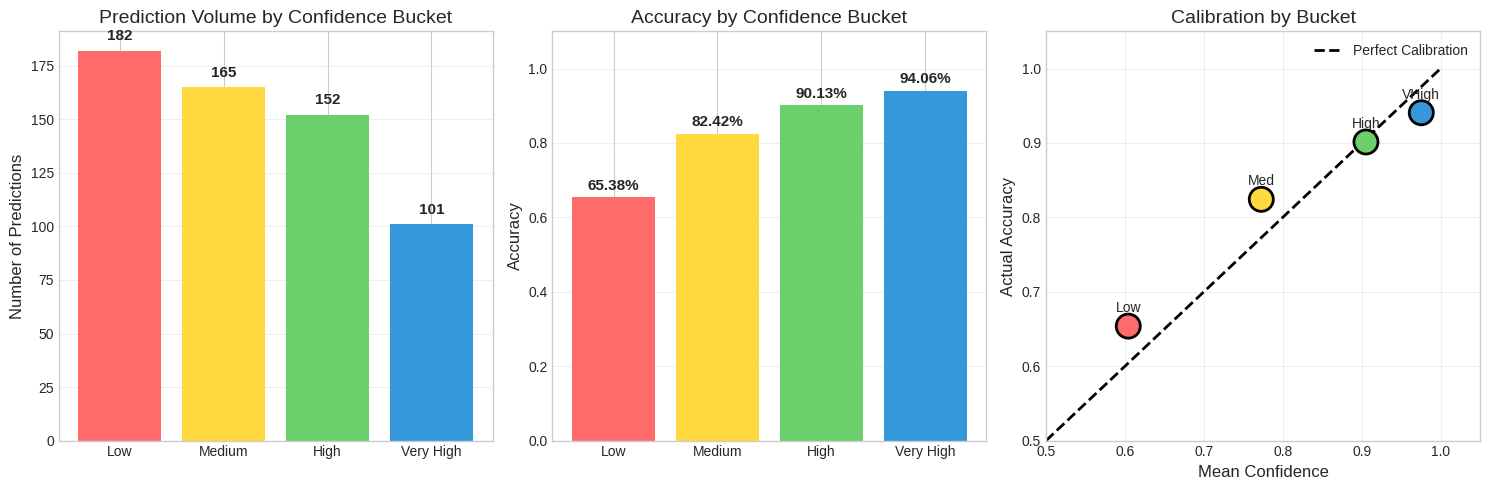

In [52]:
# Visualize bucket analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

buckets = [b['bucket'] for b in bucket_analysis]
counts = [b['count'] for b in bucket_analysis]
accuracies = [b['accuracy'] for b in bucket_analysis]
mean_confs = [b['mean_confidence'] for b in bucket_analysis]

# Plot 1: Volume by bucket
ax1 = axes[0]
bars1 = ax1.bar(range(len(buckets)), counts, color=['#ff6b6b', '#ffd93d', '#6bcf6b', '#3498db'])
ax1.set_xticks(range(len(buckets)))
ax1.set_xticklabels(['Low', 'Medium', 'High', 'Very High'])
ax1.set_ylabel('Number of Predictions', fontsize=12)
ax1.set_title('Prediction Volume by Confidence Bucket', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars1, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=11, fontweight='bold')

# Plot 2: Accuracy by bucket
ax2 = axes[1]
bars2 = ax2.bar(range(len(buckets)), accuracies, color=['#ff6b6b', '#ffd93d', '#6bcf6b', '#3498db'])
ax2.set_xticks(range(len(buckets)))
ax2.set_xticklabels(['Low', 'Medium', 'High', 'Very High'])
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy by Confidence Bucket', fontsize=14)
ax2.set_ylim([0, 1.1])
ax2.grid(True, alpha=0.3, axis='y')

# Add accuracy labels on bars
for bar, acc in zip(bars2, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold')

# Plot 3: Confidence vs Accuracy (Calibration by bucket)
ax3 = axes[2]
ax3.scatter(mean_confs, accuracies, s=300, c=['#ff6b6b', '#ffd93d', '#6bcf6b', '#3498db'],
            edgecolors='black', linewidth=2, zorder=5)
ax3.plot([0.5, 1], [0.5, 1], 'k--', label='Perfect Calibration', linewidth=2)
ax3.set_xlabel('Mean Confidence', fontsize=12)
ax3.set_ylabel('Actual Accuracy', fontsize=12)
ax3.set_title('Calibration by Bucket', fontsize=14)
ax3.set_xlim([0.5, 1.05])
ax3.set_ylim([0.5, 1.05])
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add bucket labels
for conf, acc, label in zip(mean_confs, accuracies, ['Low', 'Med', 'High', 'VHigh']):
    ax3.annotate(label, (conf, acc), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 13.7 Production Routing: Human-in-the-Loop Systems

<div style="background-color: #f8d7da; padding: 20px; border-radius: 10px; border-left: 5px solid #dc3545;">

### The Hybrid Approach

In production, we often route predictions based on confidence:

| Confidence Level | Action | Cost |
|------------------|--------|------|
| **Very High (>95%)** | Auto-approve | Low (automation) |
| **High (85-95%)** | Auto-approve with logging | Low |
| **Medium (70-85%)** | Flag for review | Medium |
| **Low (<70%)** | Require human decision | High (human labor) |

### Why This Matters

- **Business efficiency**: Automate confident decisions
- **Quality control**: Human review for uncertain cases
- **Cost optimization**: Balance accuracy vs manual effort
- **Compliance**: Audit trail for high-stakes decisions

</div>

In [53]:
# Production Routing Simulation
def simulate_production_routing(y_true, y_prob, y_pred, routing_config):
    """
    Simulate a production routing system based on confidence thresholds.

    routing_config: dict mapping route names to (min_conf, max_conf, cost_per_item)
    """
    confidence = np.maximum(y_prob, 1 - y_prob)

    results = []
    total_cost = 0
    total_correct = 0

    for route_name, (min_conf, max_conf, cost) in routing_config.items():
        mask = (confidence >= min_conf) & (confidence < max_conf)
        n_items = np.sum(mask)

        if n_items > 0:
            route_correct = np.sum(y_pred[mask] == y_true[mask])
            route_accuracy = route_correct / n_items
            route_cost = n_items * cost
        else:
            route_correct = 0
            route_accuracy = 0
            route_cost = 0

        total_cost += route_cost
        total_correct += route_correct

        results.append({
            'route': route_name,
            'min_conf': min_conf,
            'max_conf': max_conf,
            'count': n_items,
            'pct': n_items / len(y_true) * 100,
            'accuracy': route_accuracy,
            'cost_per_item': cost,
            'total_cost': route_cost,
            'correct': route_correct
        })

    return results, total_cost, total_correct / len(y_true)

# Define routing configuration (confidence_min, confidence_max, cost_per_item)
routing_config = {
    'Auto-Approve (VHigh)': (0.95, 1.01, 0.01),   # Very cheap - automated
    'Auto-Approve (High)':  (0.85, 0.95, 0.02),   # Cheap with logging
    'Review Queue':         (0.70, 0.85, 0.50),   # Moderate - needs review
    'Human Decision':       (0.50, 0.70, 2.00),   # Expensive - human labor
}

routes, total_cost, overall_accuracy = simulate_production_routing(
    y_test, y_prob_lr, y_pred_lr, routing_config
)

print("Production Routing Simulation")
print("=" * 90)
print(f"{'Route':<25} {'Count':<8} {'%':<8} {'Accuracy':<10} {'Unit Cost':<10} {'Total Cost':<12}")
print("-" * 90)

for r in routes:
    print(f"{r['route']:<25} {r['count']:<8} {r['pct']:<8.1f} {r['accuracy']:<10.4f} "
          f"${r['cost_per_item']:<9.2f} ${r['total_cost']:<11.2f}")

print("=" * 90)
print(f"\n📊 Summary Statistics:")
print(f"   Total predictions:     {len(y_test)}")
print(f"   Overall accuracy:      {overall_accuracy:.4f}")
print(f"   Total routing cost:    ${total_cost:.2f}")
print(f"   Average cost/item:     ${total_cost/len(y_test):.4f}")

# Calculate automated vs manual
auto_count = sum(r['count'] for r in routes if 'Auto' in r['route'])
manual_count = sum(r['count'] for r in routes if 'Auto' not in r['route'])
print(f"\n   🤖 Automated:          {auto_count} ({auto_count/len(y_test)*100:.1f}%)")
print(f"   👤 Manual review:      {manual_count} ({manual_count/len(y_test)*100:.1f}%)")

Production Routing Simulation
Route                     Count    %        Accuracy   Unit Cost  Total Cost  
------------------------------------------------------------------------------------------
Auto-Approve (VHigh)      101      16.8     0.9406     $0.01      $1.01       
Auto-Approve (High)       152      25.3     0.9013     $0.02      $3.04       
Review Queue              165      27.5     0.8242     $0.50      $82.50      
Human Decision            182      30.3     0.6538     $2.00      $364.00     

📊 Summary Statistics:
   Total predictions:     600
   Overall accuracy:      0.8117
   Total routing cost:    $450.55
   Average cost/item:     $0.7509

   🤖 Automated:          253 (42.2%)
   👤 Manual review:      347 (57.8%)


## 13.8 Comprehensive Confidence Analysis Dashboard

In [54]:
def confidence_analysis_dashboard(y_true, y_prob, model_name="Model"):
    """Generate a comprehensive confidence analysis dashboard."""

    # Convert to binary confidence
    confidence = np.maximum(y_prob, 1 - y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    print("=" * 80)
    print(f"CONFIDENCE ANALYSIS DASHBOARD: {model_name}")
    print("=" * 80)

    # 1. Overall Statistics
    print("\n📊 OVERALL CONFIDENCE STATISTICS")
    print("-" * 50)
    print(f"   Mean confidence:     {np.mean(confidence):.4f}")
    print(f"   Median confidence:   {np.median(confidence):.4f}")
    print(f"   Std deviation:       {np.std(confidence):.4f}")
    print(f"   Min confidence:      {np.min(confidence):.4f}")
    print(f"   Max confidence:      {np.max(confidence):.4f}")

    # 2. Calibration
    ece = calculate_ece(y_true, y_prob)
    print(f"\n📐 CALIBRATION")
    print("-" * 50)
    print(f"   Expected Calibration Error: {ece:.4f}")
    quality = "Excellent" if ece < 0.05 else "Good" if ece < 0.1 else "Needs Calibration"
    print(f"   Calibration Quality: {quality}")

    # 3. Accuracy by confidence
    print(f"\n📈 ACCURACY BY CONFIDENCE BAND")
    print("-" * 50)
    bands = [(0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.01)]
    print(f"   {'Band':<15} {'Count':<10} {'Accuracy':<10} {'Calibration Gap'}")
    print("   " + "-" * 50)

    for low, high in bands:
        mask = (confidence >= low) & (confidence < high)
        if np.sum(mask) > 0:
            band_acc = accuracy_score(y_true[mask], y_pred[mask])
            band_conf = np.mean(confidence[mask])
            gap = band_acc - band_conf
            gap_str = f"{gap:+.4f}" if gap >= 0 else f"{gap:.4f}"
            print(f"   {low:.1f}-{high:.1f}{'':>6} {np.sum(mask):<10} {band_acc:<10.4f} {gap_str}")

    # 4. Optimal Thresholds
    optimal = find_optimal_thresholds(y_true, y_prob)
    print(f"\n🎯 OPTIMAL THRESHOLDS")
    print("-" * 50)
    for method, info in optimal.items():
        print(f"   {method:<20}: {info['threshold']:.4f}")

    # 5. Routing Recommendations
    print(f"\n🔀 ROUTING RECOMMENDATIONS")
    print("-" * 50)
    high_conf = np.sum(confidence >= 0.9) / len(confidence) * 100
    med_conf = np.sum((confidence >= 0.7) & (confidence < 0.9)) / len(confidence) * 100
    low_conf = np.sum(confidence < 0.7) / len(confidence) * 100

    print(f"   Auto-approve (≥0.9): {high_conf:.1f}% of predictions")
    print(f"   Review queue (0.7-0.9): {med_conf:.1f}% of predictions")
    print(f"   Human decision (<0.7): {low_conf:.1f}% of predictions")

    print("\n" + "=" * 80)

# Generate dashboard for all models
for name, preds in predictions.items():
    confidence_analysis_dashboard(y_test, preds['prob'], name)
    print("\n")

CONFIDENCE ANALYSIS DASHBOARD: Logistic Regression

📊 OVERALL CONFIDENCE STATISTICS
--------------------------------------------------
   Mean confidence:     0.7894
   Median confidence:   0.8029
   Std deviation:       0.1465
   Min confidence:      0.5005
   Max confidence:      0.9994

📐 CALIBRATION
--------------------------------------------------
   Expected Calibration Error: 0.0491
   Calibration Quality: Excellent

📈 ACCURACY BY CONFIDENCE BAND
--------------------------------------------------
   Band            Count      Accuracy   Calibration Gap
   --------------------------------------------------
   0.5-0.6       84         0.6429     +0.0916
   0.6-0.7       98         0.6633     +0.0138
   0.7-0.8       117        0.8462     +0.0957
   0.8-0.9       110        0.8545     +0.0001
   0.9-1.0       191        0.9162     -0.0360

🎯 OPTIMAL THRESHOLDS
--------------------------------------------------
   youden_j            : 0.4505
   f1_optimal          : 0.4381
   targ

## 13.9 Task 13 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### What We've Accomplished

1. ✅ Understood classifier confidence scores and their meaning
2. ✅ Learned confidence calibration and Expected Calibration Error
3. ✅ Mastered threshold selection for different business objectives
4. ✅ Implemented confidence bucketization for analysis
5. ✅ Designed production routing systems with human-in-the-loop

### Key Concepts Cheat Sheet

| Concept | Key Insight |
|---------|-------------|
| **Confidence Scores** | Model certainty ≠ Model correctness |
| **Calibration** | Perfect: 80% confidence = 80% accuracy |
| **ECE** | Expected Calibration Error (lower is better) |
| **Threshold Selection** | 0.5 is rarely optimal for business needs |
| **Bucketization** | Group predictions for tiered decision-making |
| **Production Routing** | Route to automation vs humans by confidence |

### Best Practices

1. **Always calibrate** before using confidence for decisions
2. **Tune thresholds** to your business objectives
3. **Monitor by bucket** to catch model drift
4. **Design hybrid systems** that leverage both ML and humans

</div>

---

# Course Complete!

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 20px; color: white; text-align: center;">

## Congratulations on Completing the Classification Metrics Tutorial!

### You've Mastered 13 Essential Topics:

| Task | Topic | Key Skills |
|------|-------|------------|
| 1 | Setup & Classification Problem | Dataset creation, model training |
| 2 | Confusion Matrix | TP, TN, FP, FN, Type I/II errors |
| 3 | Accuracy & Limitations | Accuracy paradox, balanced accuracy |
| 4 | Precision & Recall | Trade-offs, when to prioritize each |
| 5 | F1, F2, Fβ Scores | Harmonic mean, MCC, Cohen's Kappa |
| 6 | ROC Curves & AUC | TPR, FPR, threshold analysis |
| 7 | Precision-Recall Curves | AUC-PR, average precision |
| 8 | Multi-class Metrics | Micro/Macro/Weighted averaging |
| 9 | Imbalanced Datasets | Resampling, appropriate metrics |
| 10 | MLOps Pipeline Metrics | Production monitoring |
| 11 | Multi-label Classification | Hamming loss, ranking metrics |
| 12 | Semi-supervised Learning | Pseudo-labels, transductive evaluation |
| 13 | Confidence & Thresholds | Calibration, bucketization, routing |

### What's Next?

- **Practice**: Apply these metrics to your own projects
- **Deep Dive**: Explore advanced calibration techniques (Platt scaling, isotonic regression)
- **Production**: Implement monitoring dashboards for your ML systems
- **Research**: Explore cutting-edge metrics for specific domains

### Remember

> "The right metric is the one that aligns with your business objective."

**Happy classifying!**

</div>

---

# PART 2: REGRESSION METRICS

---

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 30px; border-radius: 20px; color: white; text-align: center;">

## Welcome to Regression Metrics!

Now that you've mastered classification metrics, let's explore metrics for **continuous prediction problems**.

### Regression Metrics Roadmap

| Task | Topic | Complexity |
|------|-------|------------|
| **14** | Introduction to Regression & Basic Metrics | ⭐ Beginner |
| **15** | MAE, MSE, RMSE Deep Dive | ⭐ Beginner |
| **16** | R² and Adjusted R² | ⭐⭐ Intermediate |
| **17** | Advanced Regression Metrics | ⭐⭐ Intermediate |
| **18** | Regression Metrics for Different Use Cases | ⭐⭐⭐ Advanced |
| **19** | Production Regression Metrics & Monitoring | ⭐⭐⭐ Advanced |

</div>

---

# Task 14: Introduction to Regression & Basic Metrics

---

## 14.1 Learning Objectives

By the end of this task, you will:
- Understand the difference between classification and regression problems
- Learn why we need different metrics for regression
- Understand the intuition behind error metrics
- Set up a regression problem for metric exploration

---

## 14.2 Classification vs Regression

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Key Distinction

| Aspect | Classification | Regression |
|--------|----------------|------------|
| **Output** | Discrete classes | Continuous values |
| **Example** | Is it spam? (Yes/No) | What's the price? ($345.67) |
| **Prediction** | Category/Label | Number on continuous scale |
| **Error** | Wrong class | How far from true value |

### Why Different Metrics?

- Classification: Either **right or wrong** (discrete)
- Regression: Errors have **magnitude** (continuous)

In regression, predicting $100 when true is $110 is **better** than predicting $100 when true is $200!

</div>

### Real-World Regression Problems

| Domain | Prediction Target | Units |
|--------|-------------------|-------|
| **Housing** | Property price | Dollars |
| **Weather** | Temperature | Degrees |
| **Stock Market** | Future price | Currency |
| **Healthcare** | Blood pressure | mmHg |
| **Demand Forecasting** | Units sold | Count |
| **Energy** | Power consumption | kWh |

Regression Problem Setup Complete!

📊 Dataset Statistics:
   Training samples:  1050
   Test samples:      450
   Features:          10

📈 Target Variable (House Prices):
   Min:    $100,000.00
   Max:    $588,822.75
   Mean:   $368,668.42
   Median: $367,446.95
   Std:    $63,665.96


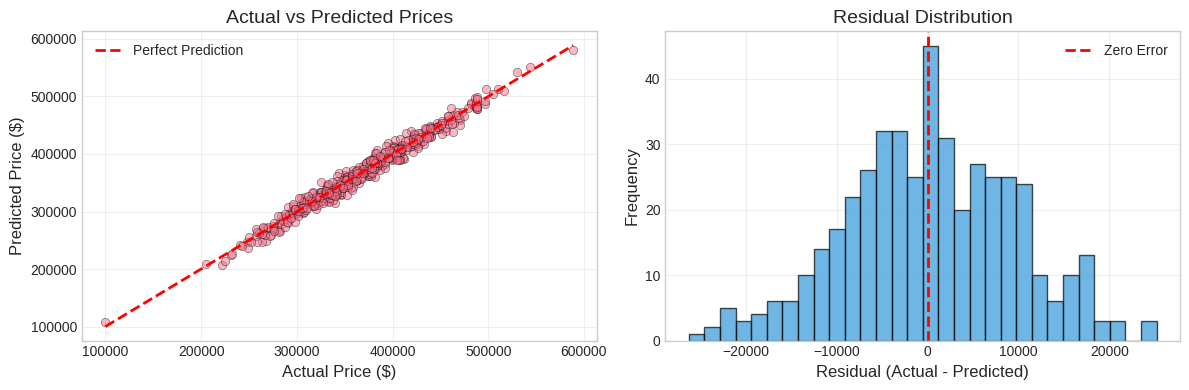

In [55]:
# Task 14: Setting Up a Regression Problem
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create a synthetic regression dataset
np.random.seed(42)

# Generate a regression problem (predicting house prices)
X_reg, y_reg = make_regression(
    n_samples=1500,
    n_features=10,
    n_informative=6,
    noise=20,
    random_state=42
)

# Scale features and target for realism
y_reg = (y_reg - y_reg.min()) / (y_reg.max() - y_reg.min()) * 500000 + 100000  # $100k - $600k range

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Train a simple model
model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = model_reg.predict(X_test_reg)

print("Regression Problem Setup Complete!")
print("=" * 60)
print(f"\n📊 Dataset Statistics:")
print(f"   Training samples:  {len(X_train_reg)}")
print(f"   Test samples:      {len(X_test_reg)}")
print(f"   Features:          {X_train_reg.shape[1]}")
print(f"\n📈 Target Variable (House Prices):")
print(f"   Min:    ${y_test_reg.min():,.2f}")
print(f"   Max:    ${y_test_reg.max():,.2f}")
print(f"   Mean:   ${y_test_reg.mean():,.2f}")
print(f"   Median: ${np.median(y_test_reg):,.2f}")
print(f"   Std:    ${y_test_reg.std():,.2f}")

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test_reg, y_pred_reg, alpha=0.5, edgecolors='black', linewidth=0.5)
ax1.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Price ($)', fontsize=12)
ax1.set_ylabel('Predicted Price ($)', fontsize=12)
ax1.set_title('Actual vs Predicted Prices', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual distribution
residuals = y_test_reg - y_pred_reg
ax2 = axes[1]
ax2.hist(residuals, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Residual (Actual - Predicted)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Task 15: MAE, MSE, RMSE Deep Dive

---

## 15.1 Learning Objectives

By the end of this task, you will:
- Understand Mean Absolute Error (MAE) and its properties
- Understand Mean Squared Error (MSE) and why we square errors
- Learn Root Mean Squared Error (RMSE) for interpretability
- Know when to use each metric
- Calculate these metrics from scratch and with scikit-learn

---

## 15.2 Mean Absolute Error (MAE)

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Definition

**MAE** is the average of absolute differences between predictions and actual values.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### Properties

| Property | Description |
|----------|-------------|
| **Units** | Same as target variable ($, °C, etc.) |
| **Interpretation** | Average error magnitude |
| **Outlier Sensitivity** | Robust to outliers |
| **Differentiability** | Not differentiable at 0 |

### Intuition

MAE tells you: **"On average, predictions are off by X units"**

</div>

In [56]:
# MAE: From Scratch and with scikit-learn

# Calculate MAE from scratch
def mae_from_scratch(y_true, y_pred):
    """Calculate Mean Absolute Error manually."""
    return np.mean(np.abs(y_true - y_pred))

# Calculate using scikit-learn
mae_scratch = mae_from_scratch(y_test_reg, y_pred_reg)
mae_sklearn = mean_absolute_error(y_test_reg, y_pred_reg)

print("Mean Absolute Error (MAE)")
print("=" * 60)
print(f"\n📊 From scratch:     ${mae_scratch:,.2f}")
print(f"📊 From sklearn:     ${mae_sklearn:,.2f}")
print(f"\n💡 Interpretation:")
print(f"   On average, our predictions are off by ${mae_sklearn:,.2f}")
print(f"\n   This means for a house actually worth $350,000,")
print(f"   we might predict anywhere from ${350000-mae_sklearn:,.2f} to ${350000+mae_sklearn:,.2f}")

Mean Absolute Error (MAE)

📊 From scratch:     $7,437.16
📊 From sklearn:     $7,437.16

💡 Interpretation:
   On average, our predictions are off by $7,437.16

   This means for a house actually worth $350,000,
   we might predict anywhere from $342,562.84 to $357,437.16


## 15.3 Mean Squared Error (MSE)

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### Definition

**MSE** squares the errors before averaging, penalizing large errors more heavily.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Properties

| Property | Description |
|----------|-------------|
| **Units** | Squared units (hard to interpret) |
| **Large Error Penalty** | Heavily penalizes big mistakes |
| **Outlier Sensitivity** | Very sensitive to outliers |
| **Differentiability** | Smooth, easy to optimize |

### Why Square?

1. Makes all errors positive
2. Penalizes large errors more than small ones
3. Creates a smooth, convex function (easy to optimize)

</div>

In [57]:
# MSE: From Scratch and with scikit-learn

def mse_from_scratch(y_true, y_pred):
    """Calculate Mean Squared Error manually."""
    return np.mean((y_true - y_pred) ** 2)

mse_scratch = mse_from_scratch(y_test_reg, y_pred_reg)
mse_sklearn = mean_squared_error(y_test_reg, y_pred_reg)

print("Mean Squared Error (MSE)")
print("=" * 60)
print(f"\n📊 From scratch:     {mse_scratch:,.2f}")
print(f"📊 From sklearn:     {mse_sklearn:,.2f}")
print(f"\n⚠️  Note: MSE is in squared units (dollars²)")
print(f"   Hard to interpret directly - that's why we use RMSE!")

# Demonstrate outlier sensitivity
print("\n" + "=" * 60)
print("Demonstrating MSE's Sensitivity to Large Errors")
print("=" * 60)

# Create predictions with one large error
y_pred_outlier = y_pred_reg.copy()
idx = np.argmin(np.abs(y_test_reg - 350000))  # Find a mid-range house
original_error = np.abs(y_test_reg[idx] - y_pred_outlier[idx])
y_pred_outlier[idx] = y_test_reg[idx] + 100000  # Add $100k error

print(f"\nOriginal MAE: ${mae_sklearn:,.2f}")
print(f"MAE with one $100k error: ${mean_absolute_error(y_test_reg, y_pred_outlier):,.2f}")
print(f"Increase: ${mean_absolute_error(y_test_reg, y_pred_outlier) - mae_sklearn:,.2f}")

print(f"\nOriginal MSE: {mse_sklearn:,.2f}")
print(f"MSE with one $100k error: {mean_squared_error(y_test_reg, y_pred_outlier):,.2f}")
print(f"Increase: {mean_squared_error(y_test_reg, y_pred_outlier) - mse_sklearn:,.2f}")
print("\n💡 Notice how MSE increases much more dramatically with outliers!")

Mean Squared Error (MSE)

📊 From scratch:     86,831,001.85
📊 From sklearn:     86,831,001.85

⚠️  Note: MSE is in squared units (dollars²)
   Hard to interpret directly - that's why we use RMSE!

Demonstrating MSE's Sensitivity to Large Errors

Original MAE: $7,437.16
MAE with one $100k error: $7,629.37
Increase: $192.22

Original MSE: 86,831,001.85
MSE with one $100k error: 108,648,102.01
Increase: 21,817,100.16

💡 Notice how MSE increases much more dramatically with outliers!


## 15.4 Root Mean Squared Error (RMSE)

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Definition

**RMSE** is simply the square root of MSE, bringing units back to original scale.

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

### Best of Both Worlds

| Property | Value |
|----------|-------|
| **Units** | Same as target (interpretable!) |
| **Large Error Penalty** | Still penalizes big mistakes |
| **Interpretation** | Typical prediction error |

### RMSE vs MAE

- **RMSE ≥ MAE** always (due to squaring)
- **RMSE = MAE** only when all errors are equal
- **Large gap** = high error variance (some predictions much worse than others)

</div>

Root Mean Squared Error (RMSE)

📊 From scratch:     $9,318.32
📊 From sklearn:     $9,318.32

Comparison: MAE vs MSE vs RMSE

Metric     Value                Interpretation
------------------------------------------------------------
MAE        $       7,437.16   Average error
MSE          86,831,001.85   Squared error (less interpretable)
RMSE       $       9,318.32   Typical error magnitude

💡 Key Insight:
   RMSE - MAE = $1,881.16
   This gap indicates error variance in our predictions.


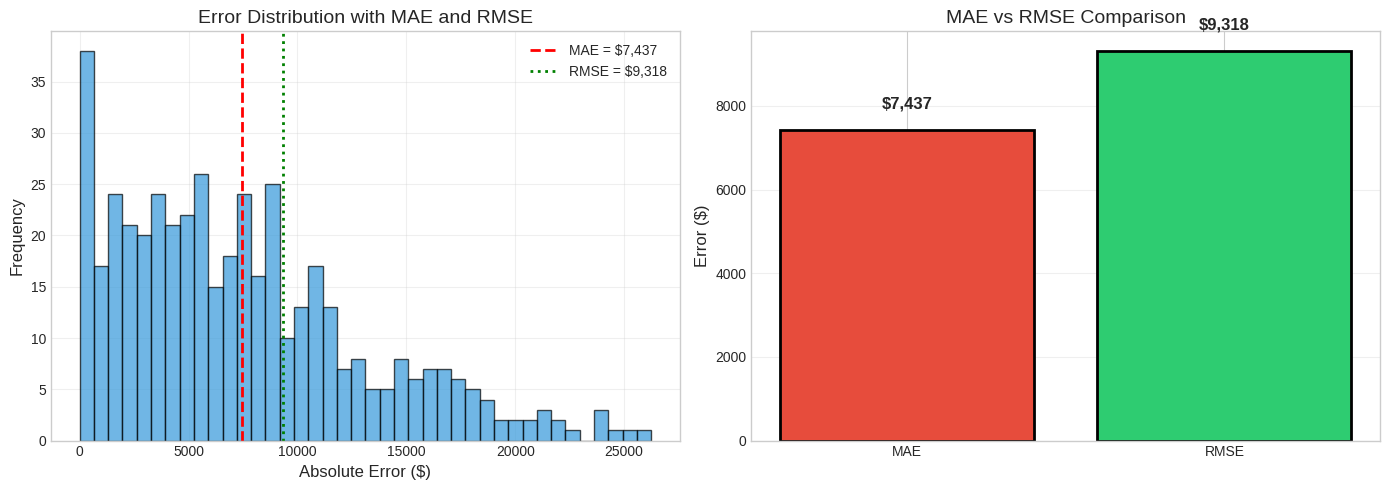

In [58]:
# RMSE: From Scratch and Comparison
def rmse_from_scratch(y_true, y_pred):
    """Calculate Root Mean Squared Error manually."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

rmse_scratch = rmse_from_scratch(y_test_reg, y_pred_reg)
rmse_sklearn = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))  # sklearn doesn't have direct RMSE

print("Root Mean Squared Error (RMSE)")
print("=" * 60)
print(f"\n📊 From scratch:     ${rmse_scratch:,.2f}")
print(f"📊 From sklearn:     ${rmse_sklearn:,.2f}")

# Comparison of all three metrics
print("\n" + "=" * 60)
print("Comparison: MAE vs MSE vs RMSE")
print("=" * 60)
print(f"\n{'Metric':<10} {'Value':<20} {'Interpretation'}")
print("-" * 60)
print(f"{'MAE':<10} ${mae_sklearn:>15,.2f}   Average error")
print(f"{'MSE':<10} {mse_sklearn:>15,.2f}   Squared error (less interpretable)")
print(f"{'RMSE':<10} ${rmse_sklearn:>15,.2f}   Typical error magnitude")

print(f"\n💡 Key Insight:")
print(f"   RMSE - MAE = ${rmse_sklearn - mae_sklearn:,.2f}")
print(f"   This gap indicates error variance in our predictions.")

# Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Error distribution showing MAE and RMSE
ax1 = axes[0]
errors = np.abs(y_test_reg - y_pred_reg)
ax1.hist(errors, bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(mae_sklearn, color='red', linestyle='--', linewidth=2, label=f'MAE = ${mae_sklearn:,.0f}')
ax1.axvline(rmse_sklearn, color='green', linestyle=':', linewidth=2, label=f'RMSE = ${rmse_sklearn:,.0f}')
ax1.set_xlabel('Absolute Error ($)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Error Distribution with MAE and RMSE', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: MAE vs RMSE relationship
ax2 = axes[1]
metrics = ['MAE', 'RMSE']
values = [mae_sklearn, rmse_sklearn]
colors = ['#e74c3c', '#2ecc71']
bars = ax2.bar(metrics, values, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('Error ($)', fontsize=12)
ax2.set_title('MAE vs RMSE Comparison', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val:,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 15.5 When to Use MAE vs RMSE

<div style="background-color: #e2d6f8; padding: 20px; border-radius: 10px; border-left: 5px solid #6f42c1;">

### Decision Guide

| Scenario | Preferred Metric | Reason |
|----------|------------------|--------|
| **All errors equally bad** | MAE | Treats all errors linearly |
| **Large errors are worse** | RMSE | Penalizes outliers more |
| **Outliers in data** | MAE | More robust |
| **Optimization** | MSE/RMSE | Smoother gradient |
| **Business reporting** | Both | Different perspectives |

### Industry Examples

| Domain | Preferred | Why |
|--------|-----------|-----|
| **Finance** | RMSE | Large errors are costly |
| **Supply Chain** | MAE | Consistent small errors preferred |
| **Weather** | RMSE | Big misses matter more |
| **Recommendation** | MAE | Treating all users fairly |

</div>

## 15.6 Task 15 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

| Metric | Formula | Units | Outlier Sensitivity |
|--------|---------|-------|---------------------|
| **MAE** | Mean(\|error\|) | Original | Low |
| **MSE** | Mean(error²) | Squared | High |
| **RMSE** | √MSE | Original | High |

### Remember

- **Report both MAE and RMSE** for complete picture
- **Large RMSE-MAE gap** = error variance issue
- **MAE** when you want robustness
- **RMSE** when large errors matter more

</div>

---

# Task 16: R² and Adjusted R²

---

## 16.1 Learning Objectives

By the end of this task, you will:
- Understand R² (Coefficient of Determination) and its interpretation
- Know the limitations of R²
- Learn Adjusted R² for model comparison
- Apply these metrics to evaluate model fit

---

## 16.2 R² (Coefficient of Determination)

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Definition

**R²** measures how much variance in the target your model explains.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

### Interpretation

| R² Value | Interpretation |
|----------|----------------|
| **1.0** | Perfect fit (explains all variance) |
| **0.8 - 1.0** | Excellent fit |
| **0.6 - 0.8** | Good fit |
| **0.4 - 0.6** | Moderate fit |
| **< 0.4** | Poor fit |
| **< 0** | Worse than mean baseline! |

### The Key Question R² Answers

**"How much better is my model than just predicting the average?"**

</div>

In [59]:
# R² (R-Squared): From Scratch and with scikit-learn

def r2_from_scratch(y_true, y_pred):
    """Calculate R² manually."""
    ss_res = np.sum((y_true - y_pred) ** 2)  # Residual sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # Total sum of squares
    return 1 - (ss_res / ss_tot)

r2_scratch = r2_from_scratch(y_test_reg, y_pred_reg)
r2_sklearn = r2_score(y_test_reg, y_pred_reg)

print("R² (Coefficient of Determination)")
print("=" * 60)
print(f"\n📊 From scratch:     {r2_scratch:.4f}")
print(f"📊 From sklearn:     {r2_sklearn:.4f}")
print(f"\n💡 Interpretation:")
print(f"   Our model explains {r2_sklearn*100:.2f}% of the variance in house prices.")
print(f"   The remaining {(1-r2_sklearn)*100:.2f}% is unexplained variance (noise, missing features, etc.)")

# Compare to baseline (predicting the mean)
y_baseline = np.full_like(y_test_reg, np.mean(y_train_reg))
mae_baseline = mean_absolute_error(y_test_reg, y_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, y_baseline))

print("\n" + "=" * 60)
print("Model vs Baseline (Predicting Mean)")
print("=" * 60)
print(f"\n{'Metric':<12} {'Baseline':<15} {'Model':<15} {'Improvement'}")
print("-" * 60)
print(f"{'MAE':<12} ${mae_baseline:<14,.2f} ${mae_sklearn:<14,.2f} {(1-mae_sklearn/mae_baseline)*100:.1f}% better")
print(f"{'RMSE':<12} ${rmse_baseline:<14,.2f} ${rmse_sklearn:<14,.2f} {(1-rmse_sklearn/rmse_baseline)*100:.1f}% better")
print(f"{'R²':<12} {'0.0000':<15} {r2_sklearn:<15.4f} Model explains variance")

R² (Coefficient of Determination)

📊 From scratch:     0.9786
📊 From sklearn:     0.9786

💡 Interpretation:
   Our model explains 97.86% of the variance in house prices.
   The remaining 2.14% is unexplained variance (noise, missing features, etc.)

Model vs Baseline (Predicting Mean)

Metric       Baseline        Model           Improvement
------------------------------------------------------------
MAE          $51,434.56      $7,437.16       85.5% better
RMSE         $64,108.41      $9,318.32       85.5% better
R²           0.0000          0.9786          Model explains variance


## 16.3 Adjusted R²

<div style="background-color: #f8d7da; padding: 20px; border-radius: 10px; border-left: 5px solid #dc3545;">

### The Problem with R²

**R² always increases (or stays same) when you add features**, even if they're useless!

This is problematic because:
- More features = higher R² (even random features)
- Makes model comparison unfair

### Solution: Adjusted R²

$$R^2_{adj} = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$

Where:
- $n$ = number of samples
- $p$ = number of features

**Adjusted R² penalizes adding features** that don't improve the model significantly.

</div>

In [60]:
# Adjusted R²: Demonstration of its value

def adjusted_r2(r2, n, p):
    """Calculate Adjusted R²."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n = len(y_test_reg)
p = X_test_reg.shape[1]

adj_r2 = adjusted_r2(r2_sklearn, n, p)

print("R² vs Adjusted R²")
print("=" * 60)
print(f"\n📊 R²:          {r2_sklearn:.4f}")
print(f"📊 Adjusted R²: {adj_r2:.4f}")
print(f"\n   Samples (n):  {n}")
print(f"   Features (p): {p}")

# Demonstrate how R² can be misleading
print("\n" + "=" * 60)
print("Demonstration: Why Adjusted R² Matters")
print("=" * 60)

# Add random (useless) features
np.random.seed(42)
n_useless_features = [0, 5, 10, 20, 50]

print(f"\n{'Useless Features':<20} {'Total Features':<18} {'R²':<12} {'Adjusted R²':<12}")
print("-" * 70)

for n_useless in n_useless_features:
    # Add random features
    if n_useless > 0:
        X_train_noisy = np.hstack([X_train_reg, np.random.randn(len(X_train_reg), n_useless)])
        X_test_noisy = np.hstack([X_test_reg, np.random.randn(len(X_test_reg), n_useless)])
    else:
        X_train_noisy = X_train_reg
        X_test_noisy = X_test_reg

    # Train model
    model_noisy = LinearRegression()
    model_noisy.fit(X_train_noisy, y_train_reg)
    y_pred_noisy = model_noisy.predict(X_test_noisy)

    # Calculate metrics
    r2_noisy = r2_score(y_test_reg, y_pred_noisy)
    total_features = X_test_noisy.shape[1]
    adj_r2_noisy = adjusted_r2(r2_noisy, len(y_test_reg), total_features)

    print(f"{n_useless:<20} {total_features:<18} {r2_noisy:<12.4f} {adj_r2_noisy:<12.4f}")

print("\n💡 Notice: R² can increase with useless features, but Adjusted R² decreases!")

R² vs Adjusted R²

📊 R²:          0.9786
📊 Adjusted R²: 0.9781

   Samples (n):  450
   Features (p): 10

Demonstration: Why Adjusted R² Matters

Useless Features     Total Features     R²           Adjusted R² 
----------------------------------------------------------------------
0                    10                 0.9786       0.9781      
5                    15                 0.9786       0.9779      
10                   20                 0.9784       0.9774      
20                   30                 0.9781       0.9766      
50                   60                 0.9779       0.9745      

💡 Notice: R² can increase with useless features, but Adjusted R² decreases!


## 16.4 Task 16 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

| Metric | Range | Use Case |
|--------|-------|----------|
| **R²** | (-∞, 1] | How much variance explained |
| **Adjusted R²** | (-∞, 1] | Fair model comparison |

### Remember

- R² = 0 means model = baseline (predicting mean)
- R² < 0 means model is worse than baseline
- Always use **Adjusted R²** when comparing models with different features
- High R² doesn't guarantee good predictions!

</div>

---

# Task 17: Advanced Regression Metrics

---

## 17.1 Learning Objectives

By the end of this task, you will:
- Learn MAPE (Mean Absolute Percentage Error) for relative errors
- Understand SMAPE and its improvements over MAPE
- Learn Median Absolute Error for robustness
- Master Max Error for worst-case analysis
- Know when to use each advanced metric

---

## 17.2 MAPE (Mean Absolute Percentage Error)

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Definition

**MAPE** expresses error as a percentage of the actual value.

$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

### Why MAPE?

- **Scale-independent**: Compare across different scales
- **Intuitive**: "On average, 5% off"
- **Business-friendly**: Easy to explain to stakeholders

### Limitations

- **Undefined when y=0**: Division by zero
- **Asymmetric**: Penalizes under-predictions more

</div>

In [61]:
# Advanced Regression Metrics
from sklearn.metrics import median_absolute_error, max_error, mean_absolute_percentage_error

def mape_from_scratch(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error."""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape_from_scratch(y_true, y_pred):
    """Calculate Symmetric Mean Absolute Percentage Error."""
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

# Calculate all advanced metrics
mape = mape_from_scratch(y_test_reg, y_pred_reg)
mape_sklearn = mean_absolute_percentage_error(y_test_reg, y_pred_reg) * 100
smape = smape_from_scratch(y_test_reg, y_pred_reg)
median_ae = median_absolute_error(y_test_reg, y_pred_reg)
max_err = max_error(y_test_reg, y_pred_reg)

print("Advanced Regression Metrics")
print("=" * 70)

print("\n📊 PERCENTAGE-BASED METRICS")
print("-" * 50)
print(f"   MAPE (from scratch):  {mape:.2f}%")
print(f"   MAPE (sklearn):       {mape_sklearn:.2f}%")
print(f"   SMAPE:                {smape:.2f}%")

print(f"\n💡 MAPE Interpretation: Predictions are off by {mape:.2f}% on average")

print("\n📊 ROBUST METRICS")
print("-" * 50)
print(f"   MAE (mean):           ${mae_sklearn:,.2f}")
print(f"   Median Absolute Error: ${median_ae:,.2f}")
print(f"\n💡 If Median AE << MAE, you have outlier predictions affecting MAE")

print("\n📊 WORST-CASE METRICS")
print("-" * 50)
print(f"   Max Error:            ${max_err:,.2f}")
print(f"\n💡 Your worst prediction was off by ${max_err:,.2f}")

Advanced Regression Metrics

📊 PERCENTAGE-BASED METRICS
--------------------------------------------------
   MAPE (from scratch):  2.09%
   MAPE (sklearn):       2.09%
   SMAPE:                2.09%

💡 MAPE Interpretation: Predictions are off by 2.09% on average

📊 ROBUST METRICS
--------------------------------------------------
   MAE (mean):           $7,437.16
   Median Absolute Error: $6,446.43

💡 If Median AE << MAE, you have outlier predictions affecting MAE

📊 WORST-CASE METRICS
--------------------------------------------------
   Max Error:            $26,240.56

💡 Your worst prediction was off by $26,240.56


---

# Task 18: Industry Best Practices - Choosing the Right Metrics

---

## 18.1 The Golden Rules of Metric Selection

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 30px; border-radius: 20px; color: white; text-align: center;">

## "The best metric is the one that aligns with your business objective"

### Universal Principles

1. **Never rely on a single metric**
2. **Match metrics to business costs**
3. **Always report baseline comparison**
4. **Use scale-appropriate metrics**
5. **Consider stakeholder interpretability**

</div>

---

## 18.2 Comprehensive Decision Guide by Scenario

<div style="background-color: #e8f4f8; padding: 20px; border-radius: 10px; border-left: 5px solid #17a2b8;">

### Scenario-Based Metric Selection

| Scenario | Primary Metrics | Secondary Metrics | Avoid |
|----------|-----------------|-------------------|-------|
| **General Reporting** | RMSE, R² | MAE, MAPE | MSE (not interpretable) |
| **Business Stakeholders** | MAPE, MAE | R² | Technical metrics |
| **Model Comparison** | Adjusted R² | RMSE | R² (misleading with features) |
| **Outlier-Heavy Data** | MAE, Median AE | SMAPE | RMSE, MSE |
| **Zero-Heavy Data** | MAE, RMSE | R² | MAPE (division by zero) |
| **Financial Forecasting** | MAPE, RMSE | Max Error | MAE alone |
| **Demand Forecasting** | SMAPE, MAE | MAPE | Asymmetric metrics |
| **Safety-Critical** | Max Error, RMSE | MAE | Averages alone |

</div>

## 18.3 Industry-Specific Best Practices

<div style="background-color: #d4edda; padding: 20px; border-radius: 10px; border-left: 5px solid #28a745;">

### Finance & Banking

| Use Case | Recommended Metrics | Why |
|----------|---------------------|-----|
| **Credit Risk** | RMSE, Max Error | Large errors = major losses |
| **Stock Prediction** | MAPE, Direction Accuracy | Relative errors matter |
| **Fraud Amount** | MAE, Median AE | Outlier robustness |
| **Revenue Forecast** | MAPE, R² | Stakeholder communication |

### Healthcare

| Use Case | Recommended Metrics | Why |
|----------|---------------------|-----|
| **Drug Dosage** | Max Error, RMSE | Safety-critical |
| **Patient Stay** | MAE, Median AE | Outlier patients |
| **Cost Prediction** | MAPE, MAE | Budget planning |

### Retail & E-commerce

| Use Case | Recommended Metrics | Why |
|----------|---------------------|-----|
| **Demand Forecast** | SMAPE, MAE | Symmetric errors |
| **Price Optimization** | MAPE, R² | Revenue impact |
| **Inventory Planning** | MAE, Max Error | Stockout cost |

### Energy & Utilities

| Use Case | Recommended Metrics | Why |
|----------|---------------------|-----|
| **Load Forecast** | MAPE, RMSE | Grid stability |
| **Renewable Output** | MAE, R² | Weather dependence |
| **Equipment Lifetime** | Max Error, RMSE | Maintenance planning |

</div>

In [62]:
# Comprehensive Regression Metrics Dashboard
def regression_metrics_dashboard(y_true, y_pred, model_name="Model"):
    """Generate a comprehensive regression metrics report."""

    n = len(y_true)

    print("=" * 80)
    print(f"COMPREHENSIVE REGRESSION METRICS DASHBOARD: {model_name}")
    print("=" * 80)

    # Error-based metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print("\n📊 ABSOLUTE ERROR METRICS")
    print("-" * 50)
    print(f"   MAE:           ${mae:>15,.2f}  (average error)")
    print(f"   MSE:           {mse:>15,.2f}  (squared error)")
    print(f"   RMSE:          ${rmse:>15,.2f}  (typical error)")

    # Percentage metrics
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    smape = smape_from_scratch(y_true, y_pred)

    print("\n📈 PERCENTAGE ERROR METRICS")
    print("-" * 50)
    print(f"   MAPE:          {mape:>15.2f}%  (percentage error)")
    print(f"   SMAPE:         {smape:>15.2f}%  (symmetric percentage)")

    # Variance explained
    r2 = r2_score(y_true, y_pred)

    print("\n📉 VARIANCE EXPLAINED")
    print("-" * 50)
    print(f"   R²:            {r2:>15.4f}  ({r2*100:.2f}% variance explained)")

    # Robust metrics
    median_ae = median_absolute_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)

    print("\n🛡️ ROBUST & WORST-CASE METRICS")
    print("-" * 50)
    print(f"   Median AE:     ${median_ae:>15,.2f}  (robust center)")
    print(f"   Max Error:     ${max_err:>15,.2f}  (worst prediction)")

    # Interpretation
    print("\n" + "=" * 80)
    print("💡 INTERPRETATION SUMMARY")
    print("=" * 80)
    print(f"\n   • On average, predictions are off by ${mae:,.2f} (MAE)")
    print(f"   • Typical error magnitude is ${rmse:,.2f} (RMSE)")
    print(f"   • Model explains {r2*100:.1f}% of the target variance")
    print(f"   • Worst single prediction was off by ${max_err:,.2f}")

    # Warning flags
    print("\n⚠️ DIAGNOSTIC FLAGS")
    print("-" * 50)
    if rmse - mae > mae * 0.3:
        print("   [!] Large RMSE-MAE gap: High error variance detected")
    if median_ae < mae * 0.8:
        print("   [!] Median AE << MAE: Outlier predictions present")
    if max_err > 3 * rmse:
        print("   [!] Max Error >> 3×RMSE: Extreme outlier prediction")
    if r2 < 0.5:
        print("   [!] R² < 0.5: Model explains less than half the variance")

    print("\n" + "=" * 80)
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

# Generate comprehensive dashboard
metrics = regression_metrics_dashboard(y_test_reg, y_pred_reg, "Linear Regression")

COMPREHENSIVE REGRESSION METRICS DASHBOARD: Linear Regression

📊 ABSOLUTE ERROR METRICS
--------------------------------------------------
   MAE:           $       7,437.16  (average error)
   MSE:             86,831,001.85  (squared error)
   RMSE:          $       9,318.32  (typical error)

📈 PERCENTAGE ERROR METRICS
--------------------------------------------------
   MAPE:                     2.09%  (percentage error)
   SMAPE:                    2.09%  (symmetric percentage)

📉 VARIANCE EXPLAINED
--------------------------------------------------
   R²:                     0.9786  (97.86% variance explained)

🛡️ ROBUST & WORST-CASE METRICS
--------------------------------------------------
   Median AE:     $       6,446.43  (robust center)
   Max Error:     $      26,240.56  (worst prediction)

💡 INTERPRETATION SUMMARY

   • On average, predictions are off by $7,437.16 (MAE)
   • Typical error magnitude is $9,318.32 (RMSE)
   • Model explains 97.9% of the target variance
   • W

## 18.4 Quick Reference: Complete Metrics Cheat Sheet

<div style="background-color: #fff3e0; padding: 20px; border-radius: 10px; border-left: 5px solid #ff9800;">

### Classification Metrics Quick Reference

| Metric | Best Value | Use When | Avoid When |
|--------|------------|----------|------------|
| **Accuracy** | 1.0 | Balanced classes | Imbalanced data |
| **Precision** | 1.0 | FP is costly | Missing positives bad |
| **Recall** | 1.0 | FN is costly | Too many FP okay |
| **F1 Score** | 1.0 | Balance P & R | Unequal costs |
| **AUC-ROC** | 1.0 | Ranking matters | Imbalanced data |
| **AUC-PR** | 1.0 | Imbalanced data | Balanced data |
| **MCC** | 1.0 | Imbalanced data | Need interpretability |

### Regression Metrics Quick Reference

| Metric | Best Value | Use When | Avoid When |
|--------|------------|----------|------------|
| **MAE** | 0 | All errors equal | Large errors worse |
| **MSE** | 0 | Optimization | Interpretation needed |
| **RMSE** | 0 | Large errors bad | Outliers in data |
| **MAPE** | 0% | % error needed | Zeros in target |
| **R²** | 1.0 | Explain variance | Comparing models |
| **Adjusted R²** | 1.0 | Model comparison | Single model |
| **Max Error** | 0 | Safety-critical | Average performance |

</div>

## 18.5 Task 18 Summary

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white;">

### Key Takeaways

1. **Match metrics to business objectives**
2. **Report multiple metrics** for complete picture
3. **Consider outliers and edge cases**
4. **Use scale-appropriate metrics**
5. **Think about stakeholder interpretability**

### Decision Framework

1. **What's the cost of errors?** → Choose sensitivity to large errors
2. **Are there outliers?** → Choose robust metrics
3. **Need percentage?** → Use MAPE/SMAPE
4. **Comparing models?** → Use Adjusted R²
5. **Safety-critical?** → Include Max Error

</div>

---

# Full Course Complete!

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 20px; color: white; text-align: center;">

## Congratulations on Completing the ML Metrics Masterclass!

### You've Mastered 18 Essential Topics:

#### Part 1: Classification Metrics (Tasks 1-13)

| Task | Topic |
|------|-------|
| 1 | Setup & Classification Problem |
| 2 | Confusion Matrix |
| 3 | Accuracy & Limitations |
| 4 | Precision & Recall |
| 5 | F1, F2, Fβ Scores |
| 6 | ROC Curves & AUC |
| 7 | Precision-Recall Curves |
| 8 | Multi-class Metrics |
| 9 | Imbalanced Datasets |
| 10 | MLOps Pipeline Metrics |
| 11 | Multi-label Classification |
| 12 | Semi-supervised Learning |
| 13 | Confidence & Thresholds |

#### Part 2: Regression Metrics (Tasks 14-18)

| Task | Topic |
|------|-------|
| 14 | Regression Introduction |
| 15 | MAE, MSE, RMSE |
| 16 | R² & Adjusted R² |
| 17 | Advanced Metrics (MAPE, etc.) |
| 18 | Industry Best Practices |

### What You Can Do Now

- **Evaluate any ML model** comprehensively
- **Choose the right metrics** for your business case
- **Communicate results** to stakeholders
- **Build production monitoring** systems
- **Debug model performance** issues

### Remember the Golden Rules

1. **Never use a single metric**
2. **Match metrics to business costs**
3. **Consider your data characteristics**
4. **Report baseline comparisons**
5. **Think about your audience**

---

**Happy modeling!**

</div>